# Homework 3

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [85]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)

# Problem 1

## Exercise 1: Data import

In [17]:
dates<-read.csv("students_HW3/70701808_periods_HW_3.csv")
msft<-read.fst("HW_3_data/HW_3_MSFT_1min.fst")
bac<-read.fst("HW_3_data/HW_3_BAC_1min.fst")
xom<-read.fst("HW_3_data/HW_3_XOM_1min.fst")

In [18]:
head(dates)

,X,Ticker,Start,End
,<int>,<chr>,<int>,<int>
1,1,MSFT,2011,2016
2,2,BAC,2012,2016
3,3,XOM,2015,2016


In [19]:
print(dim(msft))
head(msft)

[1] 933337      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:44:00,24.6994
2,2010-01-04 07:56:00,24.6673
3,2010-01-04 08:00:00,24.6593
4,2010-01-04 08:01:00,24.6272
5,2010-01-04 08:05:00,24.6192
6,2010-01-04 08:06:00,24.6192


In [20]:
print(dim(bac))
head(bac)

[1] 1134050       2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:00:00,14.0864
2,2010-01-04 07:04:00,14.0864
3,2010-01-04 07:06:00,14.0679
4,2010-01-04 07:08:00,14.0586
5,2010-01-04 07:13:00,14.0772
6,2010-01-04 07:21:00,14.1050


In [21]:
print(dim(xom))
head(xom)

[1] 882799      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:01:00,52.6728
2,2010-01-04 07:02:00,52.6728
3,2010-01-04 07:03:00,52.6728
4,2010-01-04 07:04:00,52.6345
5,2010-01-04 07:05:00,52.6728
6,2010-01-04 07:09:00,52.6728


## exercise 2: Subset the data for the correct times and dates

In [22]:
msft_xts <- xts(msft$V1, order.by = msft$index)["2011/2016"]["T07:00/T18:00"]
index(msft_xts) <- index(msft_xts) - 1
bac_xts <- xts(bac$V1, order.by = bac$index)["2012/2016"]["T07:00/T18:00"]
index(bac_xts) <- index(bac_xts) - 1
xom_xts <- xts(xom$V1, order.by = xom$index)["2015/2016"]["T07:00/T18:00"]
index(xom_xts) <- index(xom_xts) - 1

## exercise 3: create intraday returns

In [23]:
# Split the xts object by days
msft_split <- split(msft_xts, f = "days")
# Apply makeReturns to each day individually to avoid overnight returns
msft_ret_list <- lapply(msft_split, makeReturns)
# Bind the list back into a single xts object
msft_intraday_returns <- do.call(rbind, msft_ret_list)

# 2. BAC Intraday Returns
bac_split <- split(bac_xts, f = "days")
bac_ret_list <- lapply(bac_split, makeReturns)
bac_intraday_returns <- do.call(rbind, bac_ret_list)

# 3. XOM Intraday Returns
xom_split <- split(xom_xts, f = "days")
xom_ret_list <- lapply(xom_split, makeReturns)
xom_intraday_returns <- do.call(rbind, xom_ret_list)

## exercise 4: create and compare RV created from prices and returns

In [24]:
#calculate RV from prices with makeReturns=TRUE
RV_msft <- rCov(rData = msft_xts, makeReturns = TRUE)
index(RV_msft) <- as.Date(index(RV_msft))
RV_bac <- rCov(rData = bac_xts, makeReturns = TRUE)
index(RV_bac) <- as.Date(index(RV_bac))
RV_xom <- rCov(rData = xom_xts, makeReturns = TRUE)
index(RV_xom) <- as.Date(index(RV_xom))

#calculate RV from returns with makeReturns=FALSE
RV_msft_ret <- rCov(rData = msft_intraday_returns, makeReturns = FALSE)
index(RV_msft_ret) <- as.Date(index(RV_msft_ret))
RV_bac_ret <- rCov(rData = bac_intraday_returns, makeReturns = FALSE)
index(RV_bac_ret) <- as.Date(index(RV_bac_ret))
RV_xom_ret <- rCov(rData = xom_intraday_returns, makeReturns = FALSE)
index(RV_xom_ret) <- as.Date(index(RV_xom_ret))

In [25]:
# 1. MSFT Comparison
# Calculate the difference between the two RV series
diff_msft <- RV_msft - RV_msft_ret
# Calculate avg, min, and max differences (handling any potential NAs)
msft_avg <- mean(diff_msft, na.rm = TRUE)
msft_min <- min(diff_msft, na.rm = TRUE)
msft_max <- max(diff_msft, na.rm = TRUE)
# Print the results
cat("MSFT RV Differences -> Avg:", msft_avg, " | Min:", msft_min, " | Max:", msft_max, "\n")

# 2. BAC Comparison
diff_bac <- RV_bac - RV_bac_ret
bac_avg <- mean(diff_bac, na.rm = TRUE)
bac_min <- min(diff_bac, na.rm = TRUE)
bac_max <- max(diff_bac, na.rm = TRUE)
cat("BAC RV Differences  -> Avg:", bac_avg, " | Min:", bac_min, " | Max:", bac_max, "\n")

# 3. XOM Comparison
diff_xom <- RV_xom - RV_xom_ret
xom_avg <- mean(diff_xom, na.rm = TRUE)
xom_min <- min(diff_xom, na.rm = TRUE)
xom_max <- max(diff_xom, na.rm = TRUE)
cat("XOM RV Differences  -> Avg:", xom_avg, " | Min:", xom_min, " | Max:", xom_max, "\n")

MSFT RV Differences -> Avg: 0  | Min: 0  | Max: 0 
BAC RV Differences  -> Avg: 0  | Min: 0  | Max: 0 
XOM RV Differences  -> Avg: 0  | Min: 0  | Max: 0 


# exercise 5: compare intraday RVs for periods

In [26]:
# Define the time intervals and their labels for the legend
intervals <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29", "T14:30/T15:59", "T16:00/T18:00")
labels <- c("7:00-9:29", "9:30-10:59", "11:00-14:29", "14:30-15:59", "16:00-18:00")
plot_colors <- c("black", "gray30", "gray50", "gray70", "gray85")


--- MSFT Mean RV by Sub-period ---
   7:00-9:29   9:30-10:59  11:00-14:29  14:30-15:59  16:00-18:00 
7.761139e-05 6.558249e-05 5.355973e-05 3.168965e-05 2.207521e-04 


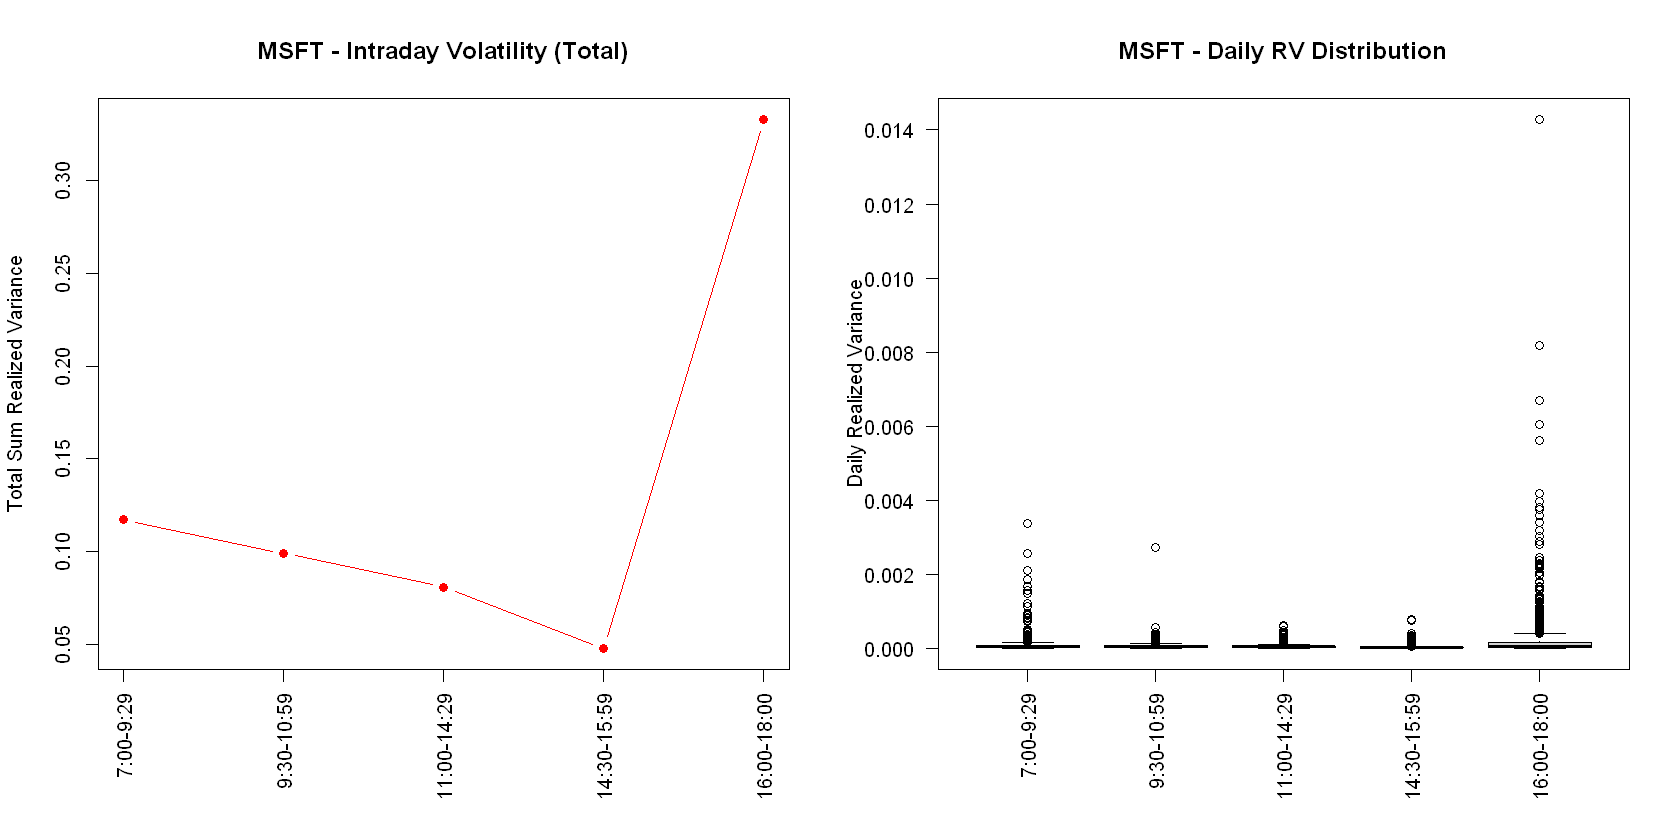

In [75]:
# 1. MSFT Sub-period RV
msft_rv_1 <- rCov(rData = msft_intraday_returns[intervals[1]], makeReturns = FALSE)
msft_rv_2 <- rCov(rData = msft_intraday_returns[intervals[2]], makeReturns = FALSE)
msft_rv_3 <- rCov(rData = msft_intraday_returns[intervals[3]], makeReturns = FALSE)
msft_rv_4 <- rCov(rData = msft_intraday_returns[intervals[4]], makeReturns = FALSE)
msft_rv_5 <- rCov(rData = msft_intraday_returns[intervals[5]], makeReturns = FALSE)

# Combine and fix index
msft_sub_rv <- cbind(msft_rv_1, msft_rv_2, msft_rv_3, msft_rv_4, msft_rv_5)
index(msft_sub_rv) <- as.Date(index(msft_sub_rv))
colnames(msft_sub_rv) <- labels


# Calculate the TOTAL sum of RV across all days for each sub-period
msft_sum_rv <- colSums(msft_sub_rv, na.rm = TRUE)
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
# Plot 1: Total Sum Line Plot
plot(msft_sum_rv, type = "b", col = "red", pch = 16, xaxt = "n", 
     xlab = "", ylab = "Total Sum Realized Variance", 
     main = "MSFT - Intraday Volatility (Total)")
axis(1, at = 1:5, labels = labels, las = 2) # las = 2 makes labels vertical

# Plot 2: Boxplot Distribution
boxplot(as.data.frame(msft_sub_rv), names = labels, las = 2, 
        ylab = "Daily Realized Variance", main = "MSFT - Daily RV Distribution")
cat("\n--- MSFT Mean RV by Sub-period ---\n")
print(colMeans(msft_sub_rv, na.rm = TRUE))


--- BAC Mean RV by Sub-period ---
   7:00-9:29   9:30-10:59  11:00-14:29  14:30-15:59  16:00-18:00 
0.0001495171 0.0001234494 0.0001130947 0.0000528366 0.0001841342 


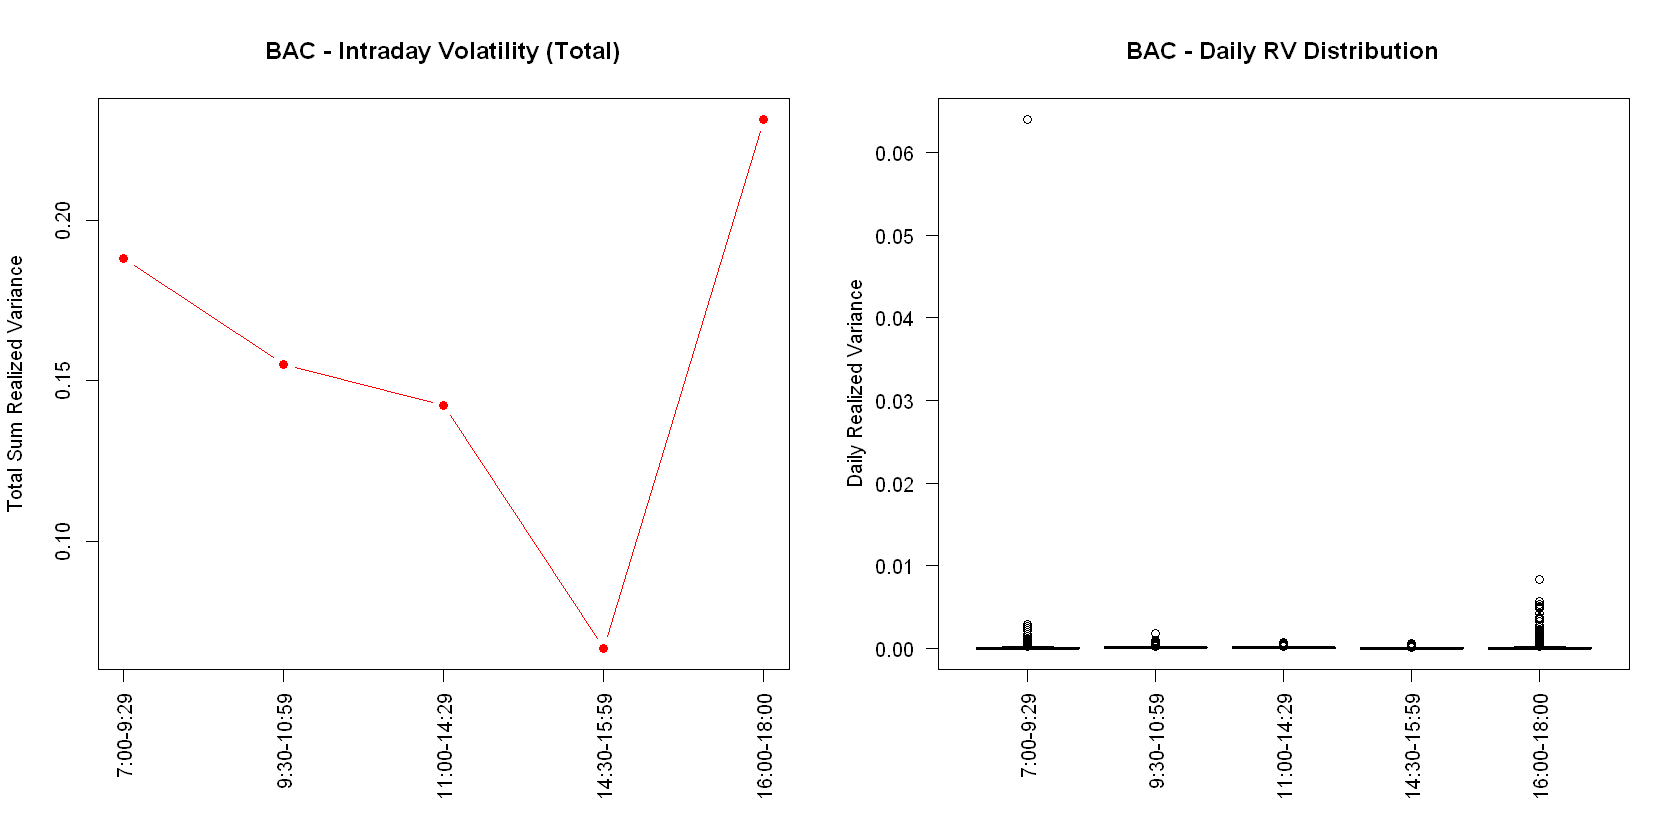

In [74]:
# 2. BAC Sub-period RV
bac_rv_1 <- rCov(rData = bac_intraday_returns[intervals[1]], makeReturns = FALSE)
bac_rv_2 <- rCov(rData = bac_intraday_returns[intervals[2]], makeReturns = FALSE)
bac_rv_3 <- rCov(rData = bac_intraday_returns[intervals[3]], makeReturns = FALSE)
bac_rv_4 <- rCov(rData = bac_intraday_returns[intervals[4]], makeReturns = FALSE)
bac_rv_5 <- rCov(rData = bac_intraday_returns[intervals[5]], makeReturns = FALSE)

# Combine and fix index
bac_sub_rv <- cbind(bac_rv_1, bac_rv_2, bac_rv_3, bac_rv_4, bac_rv_5)
index(bac_sub_rv) <- as.Date(index(bac_sub_rv))
colnames(bac_sub_rv) <- labels

bac_sum_rv <- colSums(bac_sub_rv, na.rm = TRUE)
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
plot(bac_sum_rv, type = "b", col = "red", pch = 16, xaxt = "n", 
     xlab = "", ylab = "Total Sum Realized Variance", 
     main = "BAC - Intraday Volatility (Total)")
axis(1, at = 1:5, labels = labels, las = 2)

boxplot(as.data.frame(bac_sub_rv), names = labels, las = 2, 
        ylab = "Daily Realized Variance", main = "BAC - Daily RV Distribution")
cat("\n--- BAC Mean RV by Sub-period ---\n")
print(colMeans(bac_sub_rv, na.rm = TRUE))


--- XOM Mean RV by Sub-period ---
   7:00-9:29   9:30-10:59  11:00-14:29  14:30-15:59  16:00-18:00 
3.700015e-04 6.486603e-05 4.737451e-05 2.890006e-05 1.090225e-04 


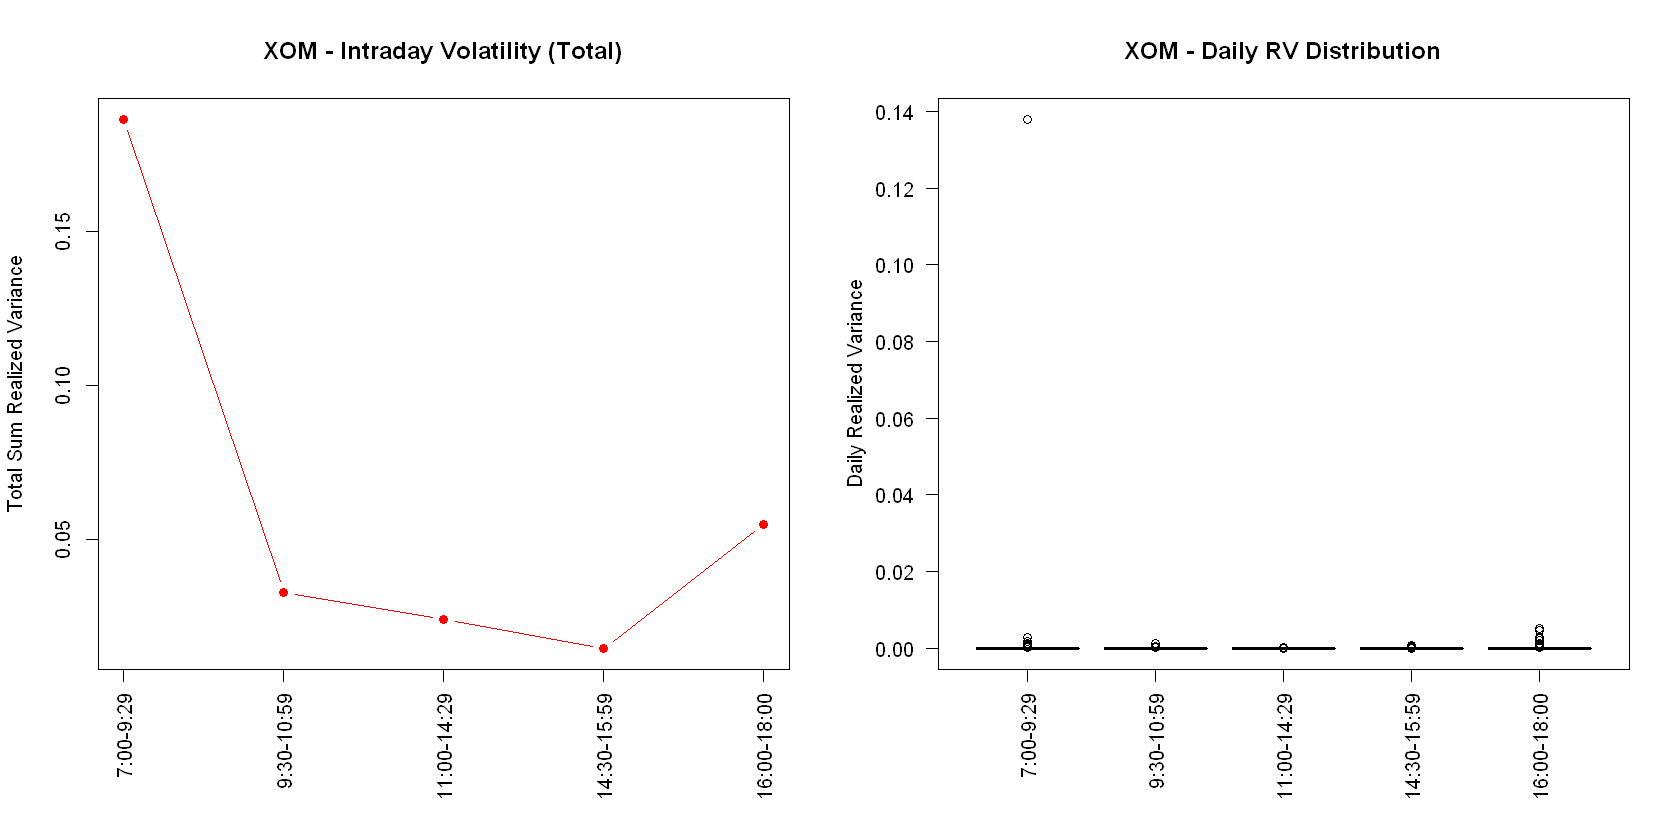

In [73]:
# 3. XOM Sub-period RV
xom_rv_1 <- rCov(rData = xom_intraday_returns[intervals[1]], makeReturns = FALSE)
xom_rv_2 <- rCov(rData = xom_intraday_returns[intervals[2]], makeReturns = FALSE)
xom_rv_3 <- rCov(rData = xom_intraday_returns[intervals[3]], makeReturns = FALSE)
xom_rv_4 <- rCov(rData = xom_intraday_returns[intervals[4]], makeReturns = FALSE)
xom_rv_5 <- rCov(rData = xom_intraday_returns[intervals[5]], makeReturns = FALSE)

# Combine and fix index
xom_sub_rv <- cbind(xom_rv_1, xom_rv_2, xom_rv_3, xom_rv_4, xom_rv_5)
index(xom_sub_rv) <- as.Date(index(xom_sub_rv))
colnames(xom_sub_rv) <- labels

xom_sum_rv <- colSums(xom_sub_rv, na.rm = TRUE)
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
plot(xom_sum_rv, type = "b", col = "red", pch = 16, xaxt = "n", 
     xlab = "", ylab = "Total Sum Realized Variance", 
     main = "XOM - Intraday Volatility (Total)")
axis(1, at = 1:5, labels = labels, las = 2)

boxplot(as.data.frame(xom_sub_rv), names = labels, las = 2, 
        ylab = "Daily Realized Variance", main = "XOM - Daily RV Distribution")
cat("\n--- XOM Mean RV by Sub-period ---\n")
print(colMeans(xom_sub_rv, na.rm = TRUE))

# exercise 6: compare intraday sub RVs sums with daily RV


--- MSFT Additivity Summary ---
Mean Difference: 2.881034e-21
Max Difference : 8.673617e-19
Min Difference : -8.673617e-19


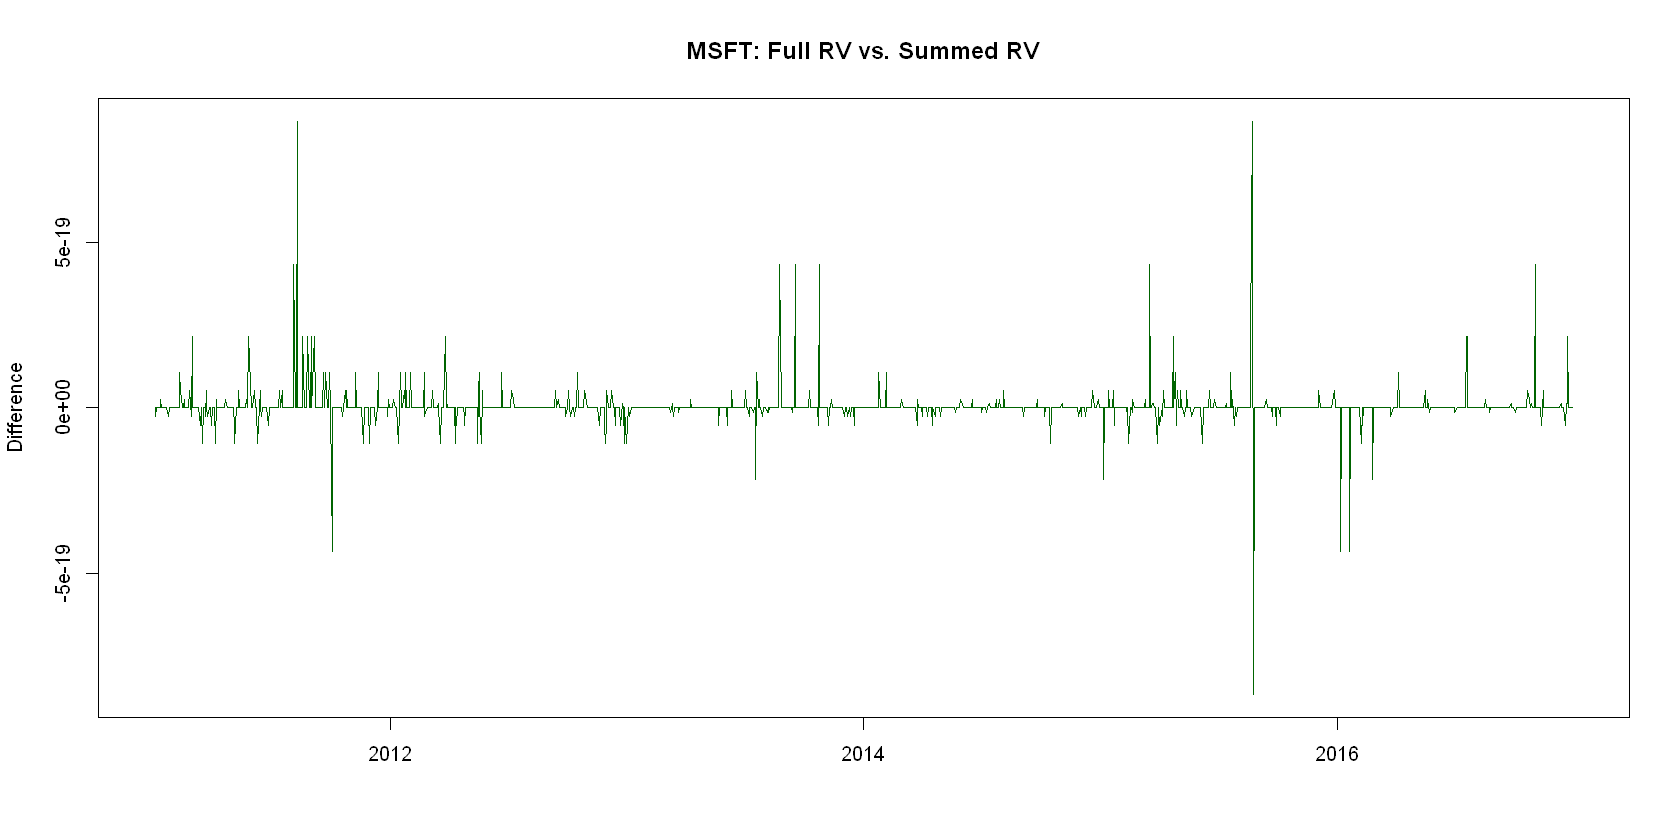

In [41]:
# 1. MSFT Difference
msft_rv_daily <- rCov(na.omit(msft_intraday_returns["T07:00/T18:00"]), makeReturns = FALSE)
index(msft_rv_daily) <- as.Date(index(msft_rv_daily))
colnames(msft_rv_daily) <- "Full_RV"

msft_combined <- msft_rv_daily
for (i in seq_along(intervals)) {
  sub_ret      <- na.omit(msft_intraday_returns[intervals[i]])
  daily_sub_rv <- rCov(sub_ret, makeReturns = FALSE)
  index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
  colnames(daily_sub_rv) <- paste0("P", i)
  msft_combined <- merge(msft_combined, daily_sub_rv, join = "left")
}

msft_combined[is.na(msft_combined)] <- 0

msft_rv_summed <- rowSums(msft_combined[, 2:6])
msft_rv_diff   <- msft_combined[, 1] - msft_rv_summed

plot.zoo(msft_rv_diff, col = "darkgreen", xlab = "", ylab = "Difference",
         main = "MSFT: Full RV vs. Summed RV")

cat(sprintf("\n--- MSFT Additivity Summary ---\n"))
cat(sprintf("Mean Difference: %e\n", mean(msft_rv_diff, na.rm = TRUE)))
cat(sprintf("Max Difference : %e\n", max(msft_rv_diff,  na.rm = TRUE)))
cat(sprintf("Min Difference : %e\n", min(msft_rv_diff,  na.rm = TRUE)))


--- BAC Additivity Summary ---
Mean Difference: 3.662845e-22
Max Difference : 4.336809e-19
Min Difference : -8.673617e-19


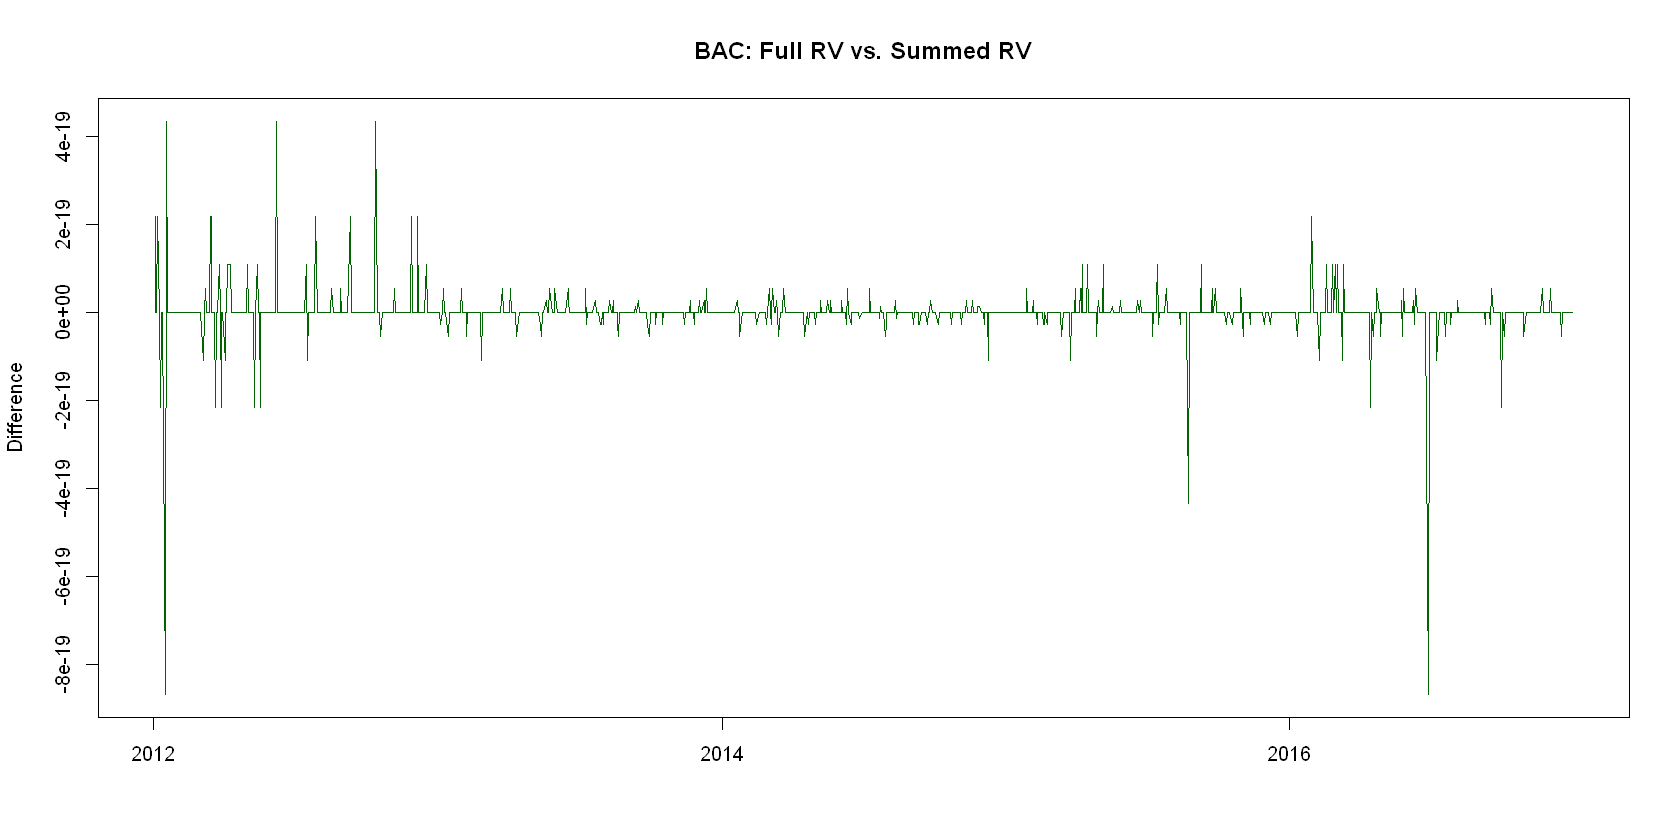

In [42]:
# 2. BAC Difference
bac_rv_daily <- rCov(na.omit(bac_intraday_returns["T07:00/T18:00"]), makeReturns = FALSE)
index(bac_rv_daily) <- as.Date(index(bac_rv_daily))
colnames(bac_rv_daily) <- "Full_RV"

bac_combined <- bac_rv_daily
for (i in seq_along(intervals)) {
  sub_ret      <- na.omit(bac_intraday_returns[intervals[i]])
  daily_sub_rv <- rCov(sub_ret, makeReturns = FALSE)
  index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
  colnames(daily_sub_rv) <- paste0("P", i)
  bac_combined <- merge(bac_combined, daily_sub_rv, join = "left")
}

bac_combined[is.na(bac_combined)] <- 0

bac_rv_summed <- rowSums(bac_combined[, 2:6])
bac_rv_diff   <- bac_combined[, 1] - bac_rv_summed

plot.zoo(bac_rv_diff, col = "darkgreen", xlab = "", ylab = "Difference",
         main = "BAC: Full RV vs. Summed RV")

cat(sprintf("\n--- BAC Additivity Summary ---\n"))
cat(sprintf("Mean Difference: %e\n", mean(bac_rv_diff, na.rm = TRUE)))
cat(sprintf("Max Difference : %e\n", max(bac_rv_diff,  na.rm = TRUE)))
cat(sprintf("Min Difference : %e\n", min(bac_rv_diff,  na.rm = TRUE)))


--- XOM Additivity Summary ---
Mean Difference: 1.344497e-21
Max Difference : 4.336809e-19
Min Difference : -2.168404e-19


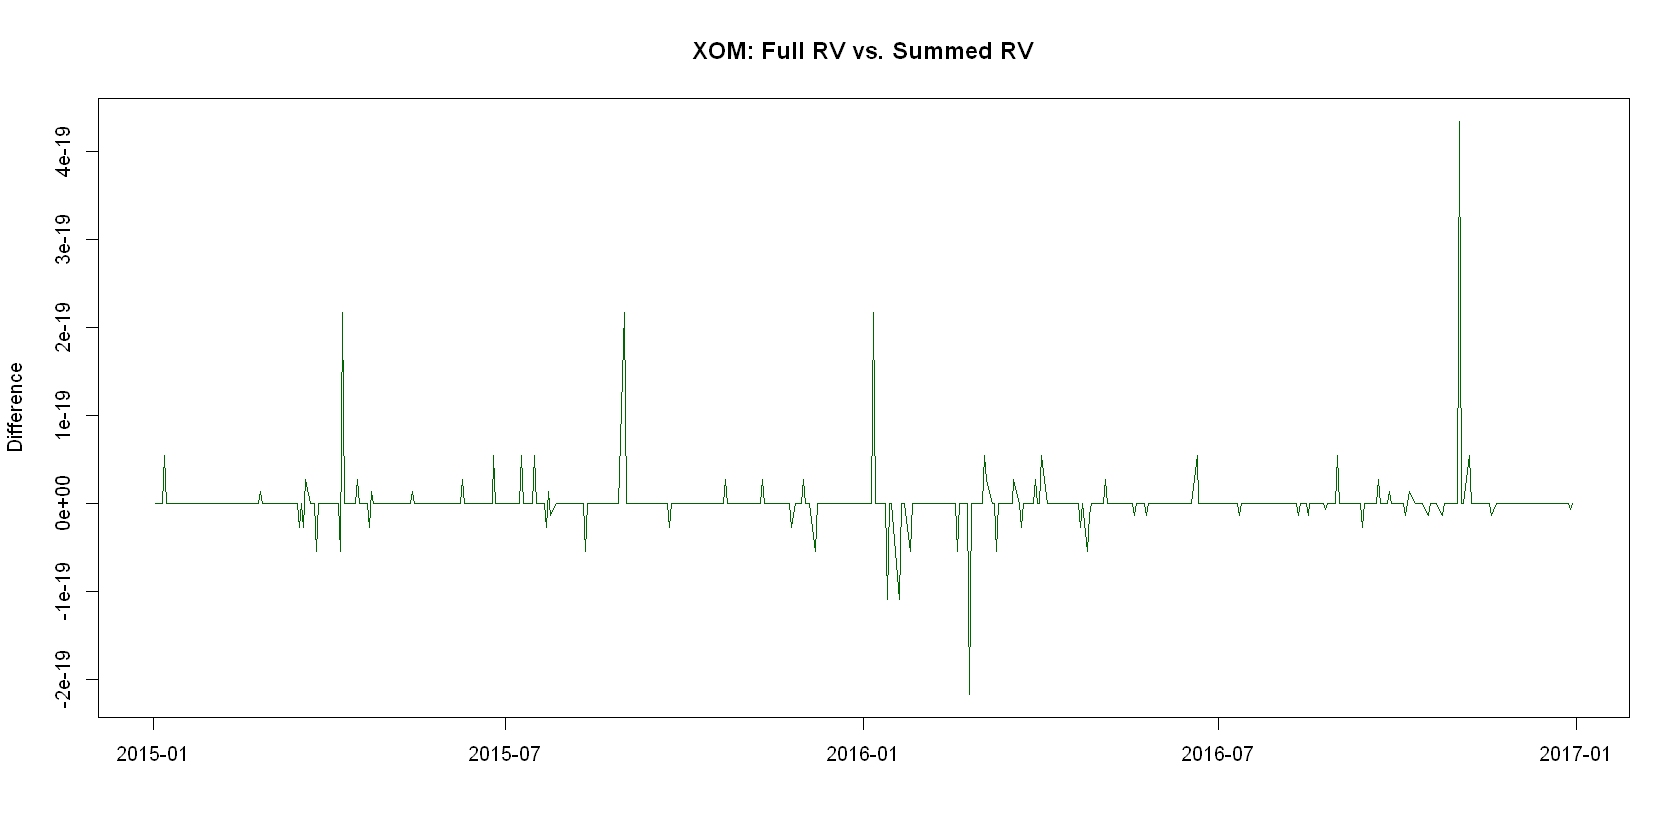

In [43]:
# 3. XOM Difference
xom_rv_daily <- rCov(na.omit(xom_intraday_returns["T07:00/T18:00"]), makeReturns = FALSE)
index(xom_rv_daily) <- as.Date(index(xom_rv_daily))
colnames(xom_rv_daily) <- "Full_RV"

xom_combined <- xom_rv_daily
for (i in seq_along(intervals)) {
  sub_ret      <- na.omit(xom_intraday_returns[intervals[i]])
  daily_sub_rv <- rCov(sub_ret, makeReturns = FALSE)
  index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
  colnames(daily_sub_rv) <- paste0("P", i)
  xom_combined <- merge(xom_combined, daily_sub_rv, join = "left")
}

xom_combined[is.na(xom_combined)] <- 0

xom_rv_summed <- rowSums(xom_combined[, 2:6])
xom_rv_diff   <- xom_combined[, 1] - xom_rv_summed

plot.zoo(xom_rv_diff, col = "darkgreen", xlab = "", ylab = "Difference",
         main = "XOM: Full RV vs. Summed RV")

cat(sprintf("\n--- XOM Additivity Summary ---\n"))
cat(sprintf("Mean Difference: %e\n", mean(xom_rv_diff, na.rm = TRUE)))
cat(sprintf("Max Difference : %e\n", max(xom_rv_diff,  na.rm = TRUE)))
cat(sprintf("Min Difference : %e\n", min(xom_rv_diff,  na.rm = TRUE)))

## exercise 7: shares of intraday sub RVs on total

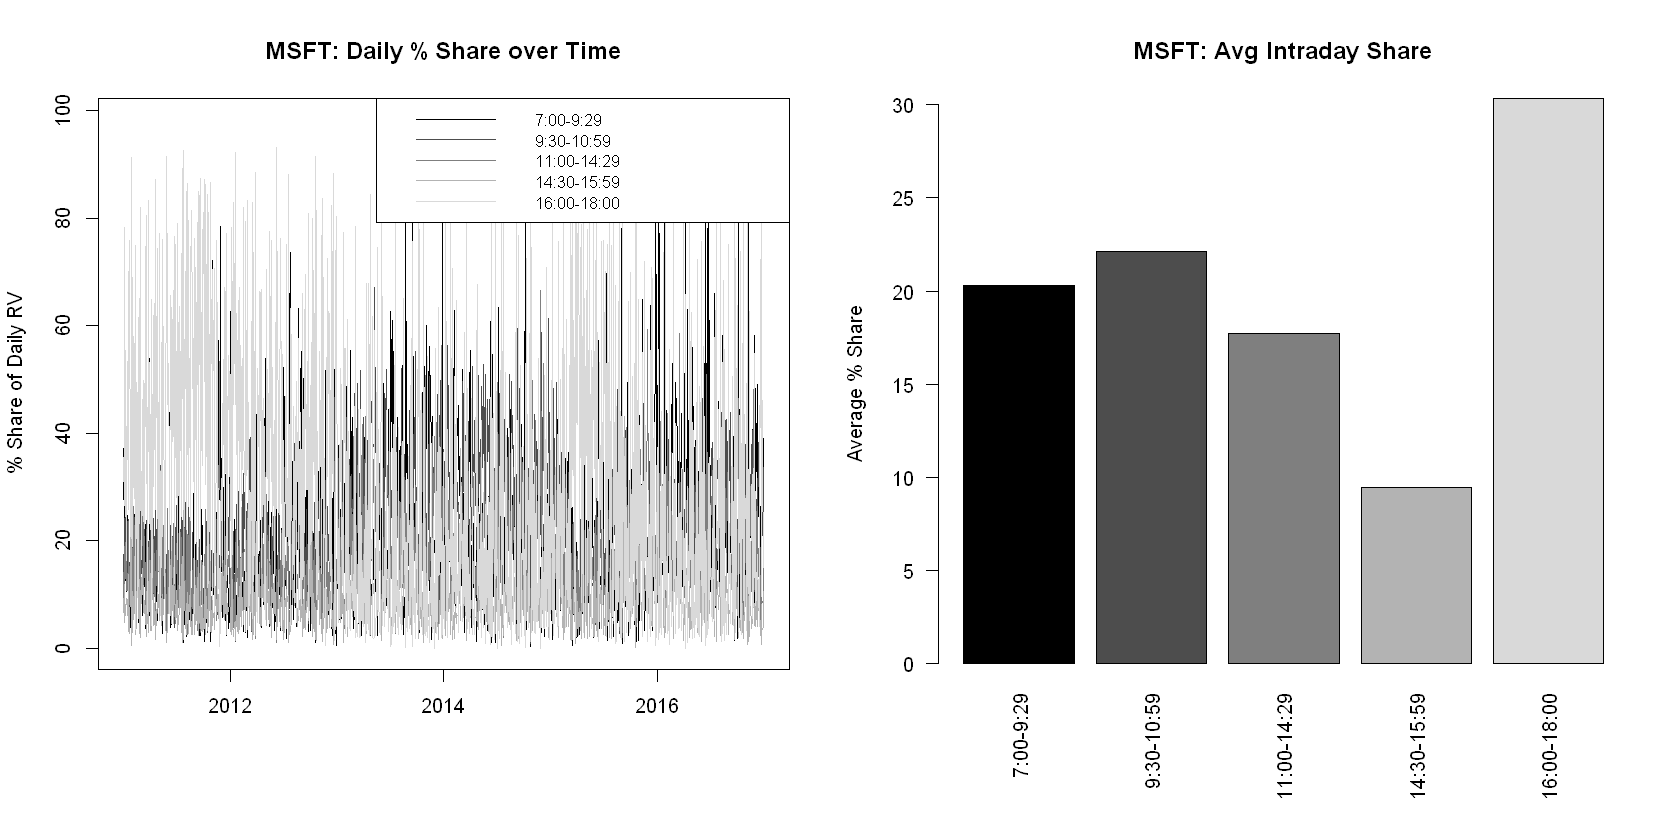

In [46]:
# 1. MSFT Percentage Share
# Use as.numeric() on the denominator to fix array mismatch
msft_pct <- (msft_combined[, 2:6] / as.numeric(msft_combined[, 1])) * 100

# Handle any potential division by zero
msft_pct[is.na(msft_pct) | msft_pct == Inf] <- 0
colnames(msft_pct) <- labels

msft_avg_pct <- colMeans(msft_pct, na.rm = TRUE)

par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
plot.zoo(msft_pct, screens = 1, col = plot_colors, xlab = "", ylab = "% Share of Daily RV",
         main = "MSFT: Daily % Share over Time")
legend("topright", legend = labels, lty = 1, col = plot_colors, cex = 0.8)

barplot(msft_avg_pct, col = plot_colors, las = 2, ylab = "Average % Share",
        main = "MSFT: Avg Intraday Share")


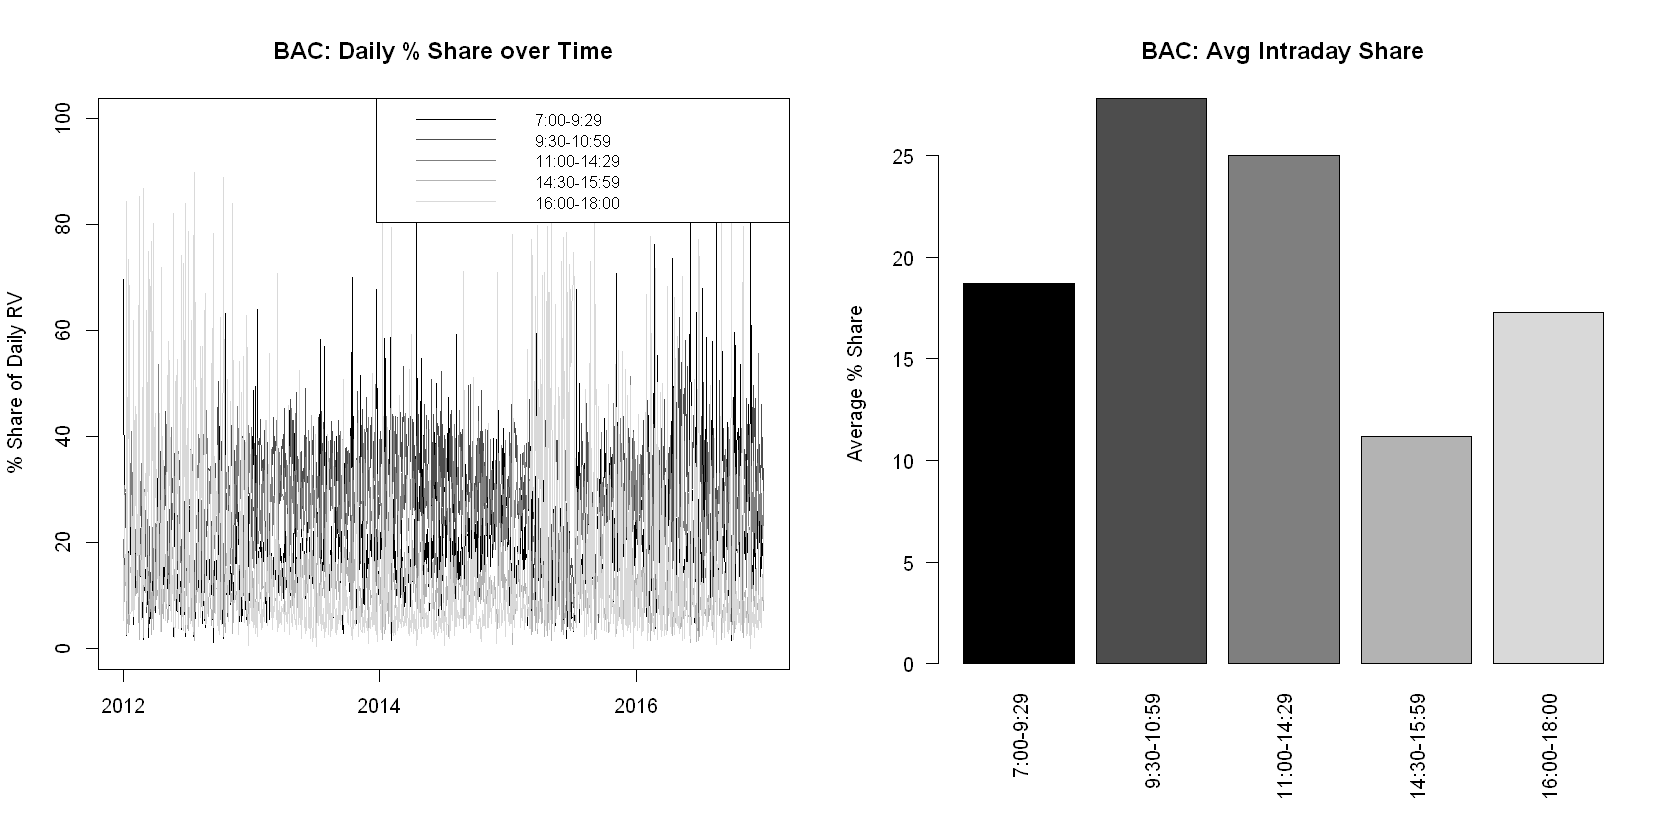

In [47]:
# 2. BAC Percentage Share
bac_pct <- (bac_combined[, 2:6] / as.numeric(bac_combined[, 1])) * 100

bac_pct[is.na(bac_pct) | bac_pct == Inf] <- 0
colnames(bac_pct) <- labels

bac_avg_pct <- colMeans(bac_pct, na.rm = TRUE)

par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
plot.zoo(bac_pct, screens = 1, col = plot_colors, xlab = "", ylab = "% Share of Daily RV",
         main = "BAC: Daily % Share over Time")
legend("topright", legend = labels, lty = 1, col = plot_colors, cex = 0.8)

barplot(bac_avg_pct, col = plot_colors, las = 2, ylab = "Average % Share",
        main = "BAC: Avg Intraday Share")

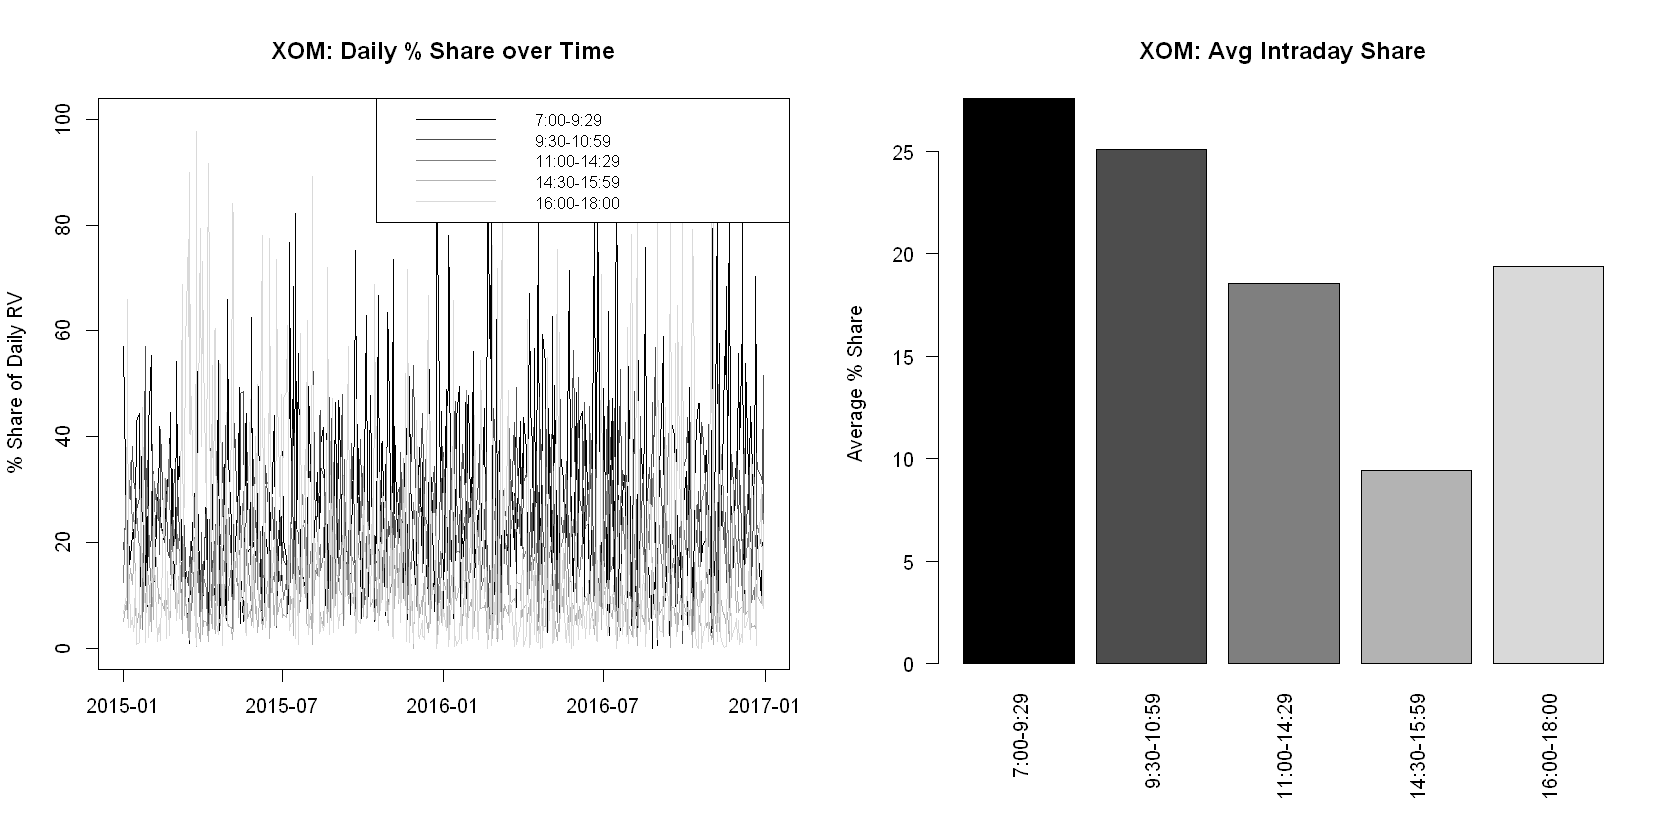

In [83]:
# 3. XOM Percentage Share
xom_pct <- (xom_combined[, 2:6] / as.numeric(xom_combined[, 1])) * 100

xom_pct[is.na(xom_pct) | xom_pct == Inf] <- 0
colnames(xom_pct) <- labels

xom_avg_pct <- colMeans(xom_pct, na.rm = TRUE)

par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
plot.zoo(xom_pct, screens = 1, col = plot_colors, xlab = "", ylab = "% Share of Daily RV",
         main = "XOM: Daily % Share over Time")
legend("topright", legend = labels, lty = 1, col = plot_colors, cex = 0.8)

barplot(xom_avg_pct, col = plot_colors, las = 2, ylab = "Average % Share",
        main = "XOM: Avg Intraday Share")

## exercise 8: repeat with prices instead of returns

In [55]:
# Helper function to safely calculate sub-period RV
safe_rv <- function(x) {
  if (nrow(x) > 1) {
    xts(as.numeric(rCov(x, makeReturns = TRUE)), order.by = as.Date(index(x)[1]))
  } else if (nrow(x) == 1) {
    xts(0, order.by = as.Date(index(x)[1]))
  } else {
    NULL
  }
}
# 1. MSFT Prices (Using pre-calculated RV_msft)
msft_combined_pr <- RV_msft
colnames(msft_combined_pr) <- "Full_RV"

for (i in seq_along(intervals)) {
  sub_split <- split(na.omit(msft_xts[intervals[i]]), f = "days")
  daily_sub_rv <- do.call(rbind, lapply(sub_split, safe_rv))
  colnames(daily_sub_rv) <- paste0("P", i)
  msft_combined_pr <- merge(msft_combined_pr, daily_sub_rv, join = "left")
}
msft_combined_pr[is.na(msft_combined_pr)] <- 0

# 2. BAC Prices (Using pre-calculated RV_bac)
bac_combined_pr <- RV_bac
colnames(bac_combined_pr) <- "Full_RV"

for (i in seq_along(intervals)) {
  sub_split <- split(na.omit(bac_xts[intervals[i]]), f = "days")
  daily_sub_rv <- do.call(rbind, lapply(sub_split, safe_rv))
  colnames(daily_sub_rv) <- paste0("P", i)
  bac_combined_pr <- merge(bac_combined_pr, daily_sub_rv, join = "left")
}
bac_combined_pr[is.na(bac_combined_pr)] <- 0


# 3. XOM Prices (Using pre-calculated RV_xom)
xom_combined_pr <- RV_xom
colnames(xom_combined_pr) <- "Full_RV"

for (i in seq_along(intervals)) {
  sub_split <- split(na.omit(xom_xts[intervals[i]]), f = "days")
  daily_sub_rv <- do.call(rbind, lapply(sub_split, safe_rv))
  colnames(daily_sub_rv) <- paste0("P", i)
  xom_combined_pr <- merge(xom_combined_pr, daily_sub_rv, join = "left")
}
xom_combined_pr[is.na(xom_combined_pr)] <- 0

### 8.5: compare intraday RV


--- MSFT Mean RV by Sub-period ---
          P1           P2           P3           P4           P5 
7.680847e-05 6.263976e-05 5.317954e-05 3.140253e-05 2.144205e-04 


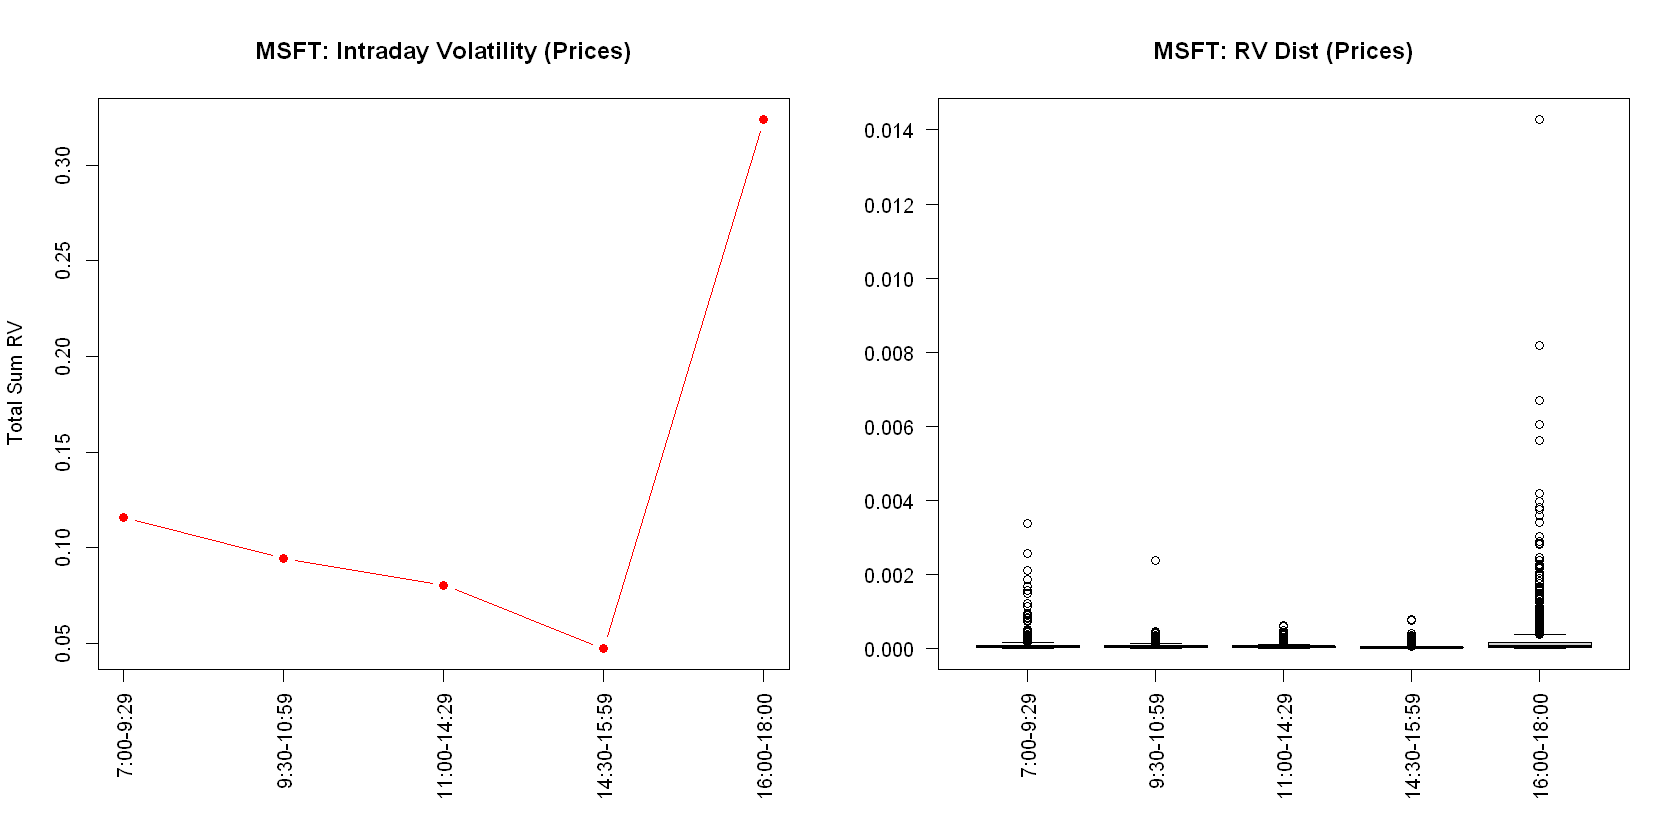

In [68]:
# MSFT
par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
plot(colSums(msft_combined_pr[, 2:6], na.rm = TRUE), type = "b", col = "red", pch = 16, xaxt = "n", 
     xlab = "", ylab = "Total Sum RV", main = "MSFT: Intraday Volatility (Prices)")
axis(1, at = 1:5, labels = labels, las = 2)
boxplot(as.data.frame(msft_combined_pr[, 2:6]), names = labels, las = 2, main = "MSFT: RV Dist (Prices)")
cat("\n--- MSFT Mean RV by Sub-period ---\n")
print(colMeans(msft_combined_pr[, 2:6], na.rm = TRUE))


--- BAC Mean RV by Sub-period ---
          P1           P2           P3           P4           P5 
1.467764e-04 1.186846e-04 1.123175e-04 5.228767e-05 1.815049e-04 


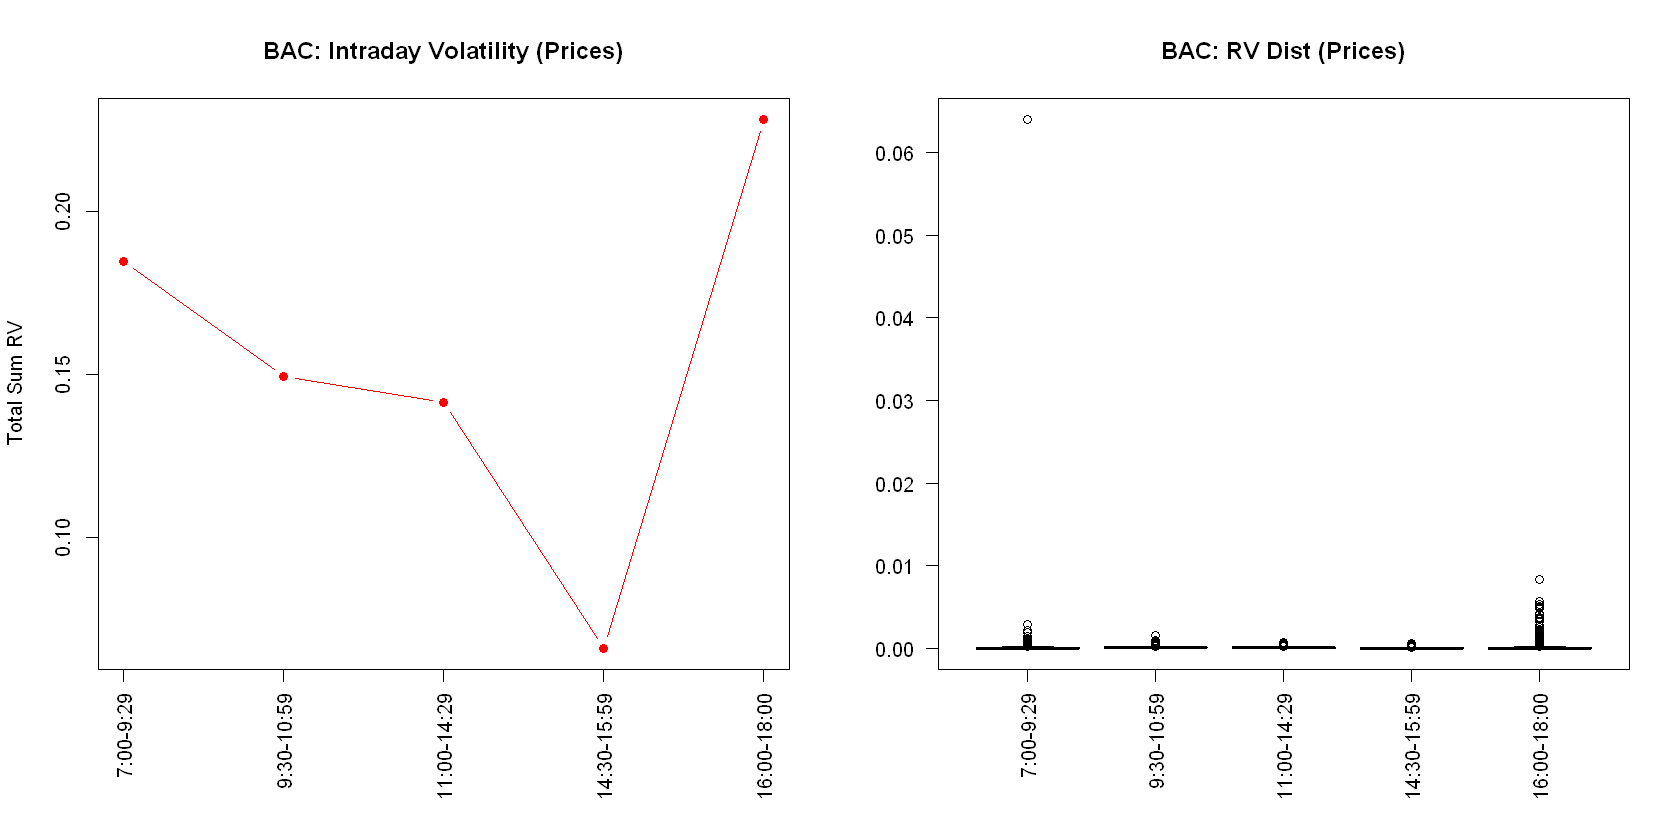

In [70]:
# BAC
par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
plot(colSums(bac_combined_pr[, 2:6], na.rm = TRUE), type = "b", col = "red", pch = 16, xaxt = "n", 
     xlab = "", ylab = "Total Sum RV", main = "BAC: Intraday Volatility (Prices)")
axis(1, at = 1:5, labels = labels, las = 2)
boxplot(as.data.frame(bac_combined_pr[, 2:6]), names = labels, las = 2, main = "BAC: RV Dist (Prices)")
cat("\n--- BAC Mean RV by Sub-period ---\n")
print(colMeans(bac_combined_pr[, 2:6], na.rm = TRUE))


--- XOM Mean RV by Sub-period ---
          P1           P2           P3           P4           P5 
3.696850e-04 6.185005e-05 4.694854e-05 2.866475e-05 9.969956e-05 


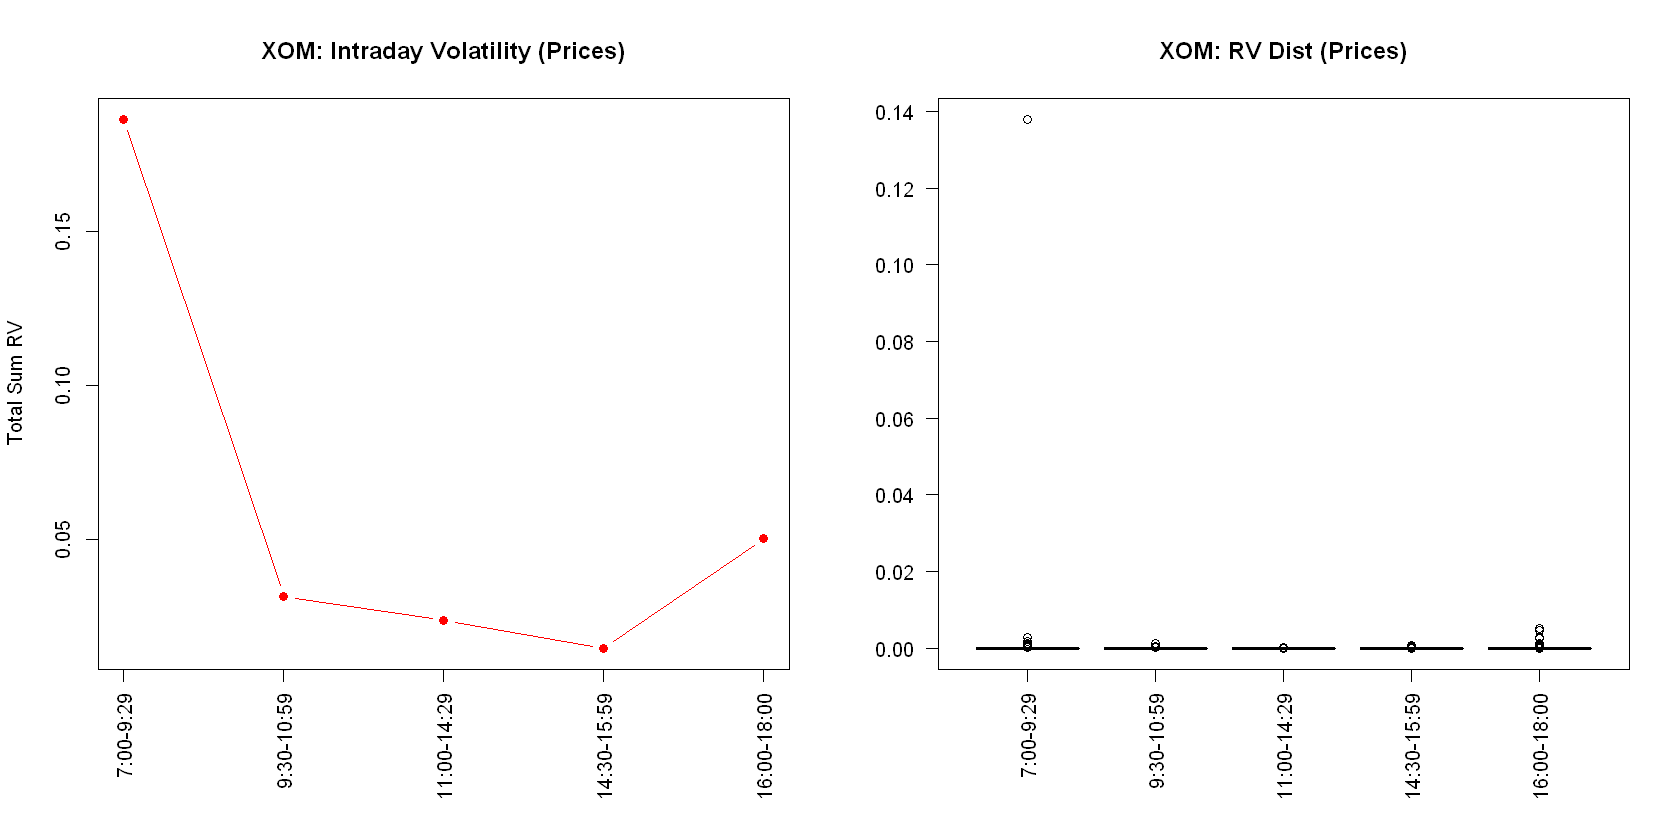

In [71]:
# XOM
par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
plot(colSums(xom_combined_pr[, 2:6], na.rm = TRUE), type = "b", col = "red", pch = 16, xaxt = "n", 
     xlab = "", ylab = "Total Sum RV", main = "XOM: Intraday Volatility (Prices)")
axis(1, at = 1:5, labels = labels, las = 2)
boxplot(as.data.frame(xom_combined_pr[, 2:6]), names = labels, las = 2, main = "XOM: RV Dist (Prices)")
cat("\n--- XOM Mean RV by Sub-period ---\n")
print(colMeans(xom_combined_pr[, 2:6], na.rm = TRUE))

### 8.6: additivity


--- MSFT Additivity Summary ---
Mean Difference: 1.045217e-05
Max Difference : 6.640502e-04
Min Difference : 4.830225e-09


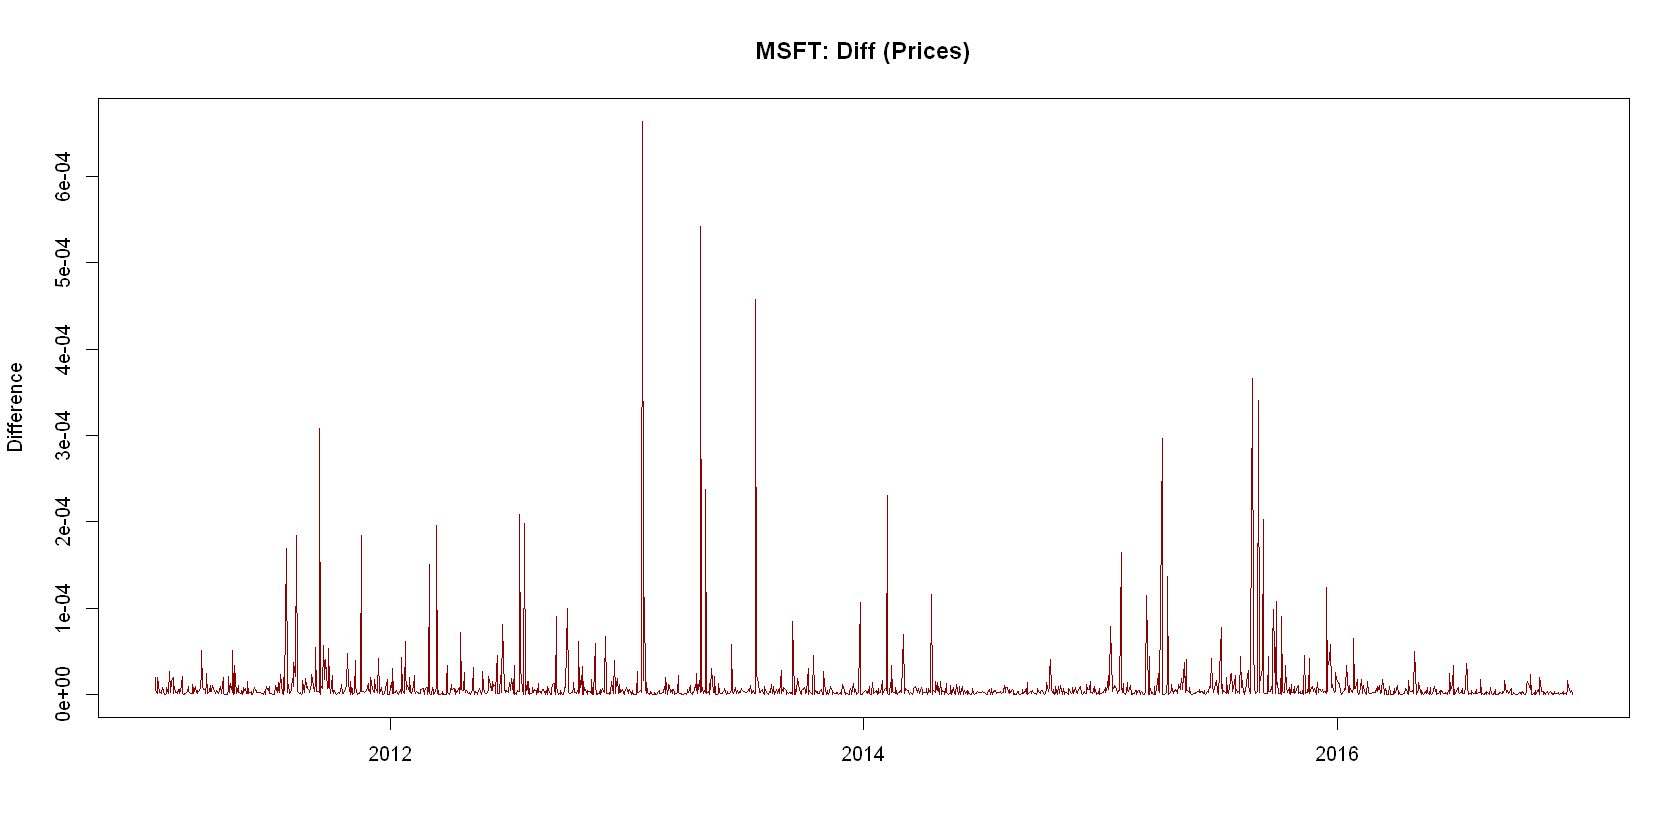

In [62]:
msft_rv_diff_pr <- msft_combined_pr[, 1] - rowSums(msft_combined_pr[, 2:6])
plot.zoo(msft_rv_diff_pr, col = "darkred", xlab = "", ylab = "Difference", main = "MSFT: Diff (Prices)")
cat(sprintf("\n--- MSFT Additivity Summary ---\n"))
cat(sprintf("Mean Difference: %e\n", mean(msft_rv_diff_pr, na.rm = TRUE)))
cat(sprintf("Max Difference : %e\n", max(msft_rv_diff_pr,  na.rm = TRUE)))
cat(sprintf("Min Difference : %e\n", min(msft_rv_diff_pr,  na.rm = TRUE)))


--- BAC Additivity Summary ---
Mean Difference: 1.146090e-05
Max Difference : 5.456603e-04
Min Difference : 0.000000e+00


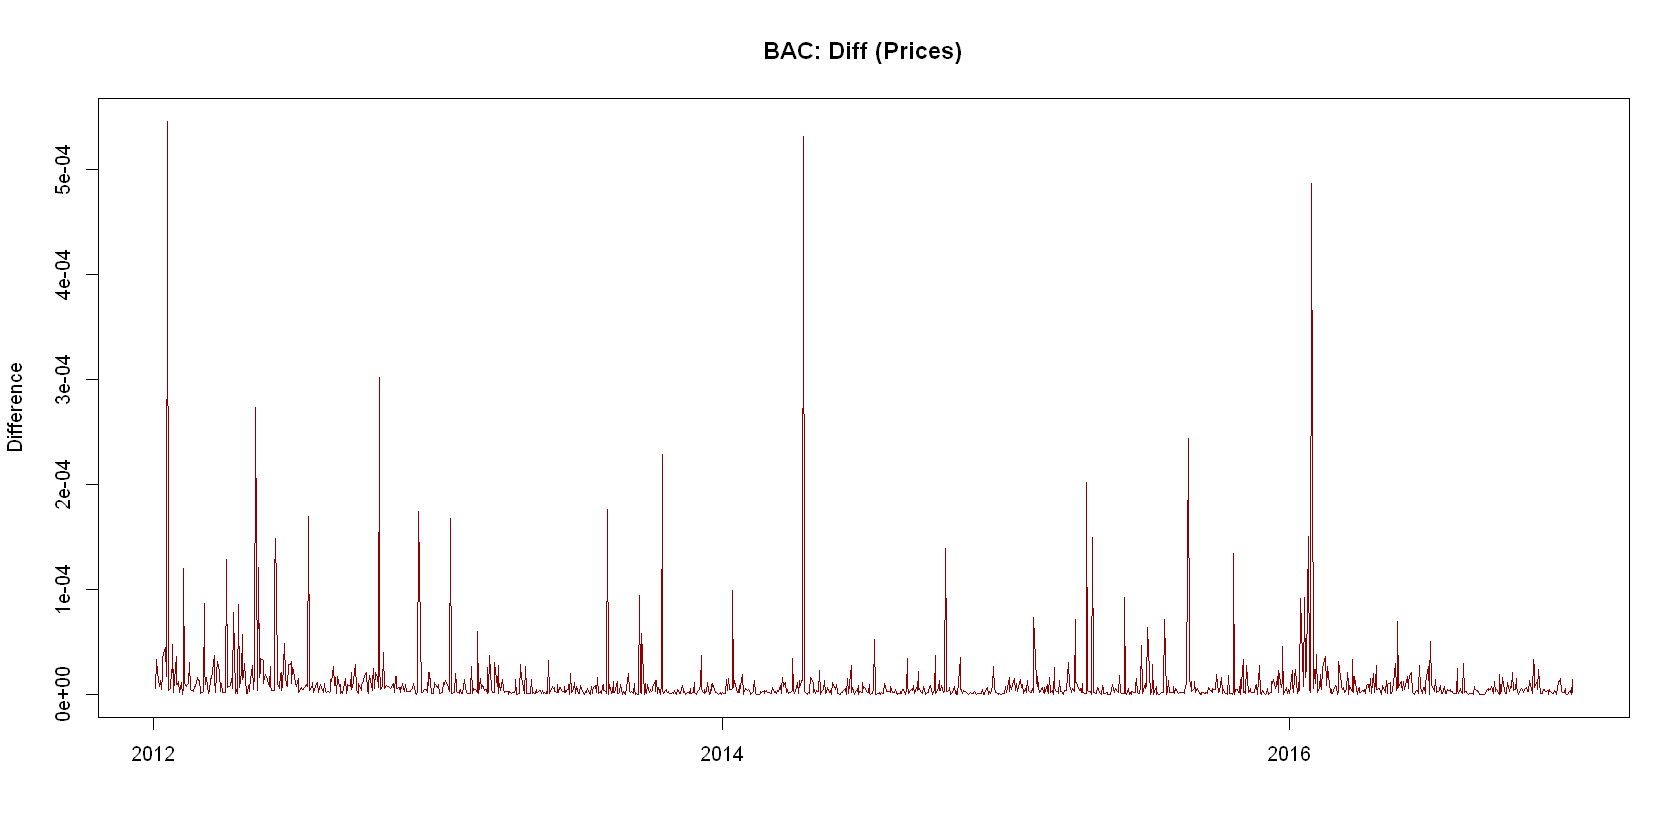

In [63]:
bac_rv_diff_pr  <- bac_combined_pr[, 1] - rowSums(bac_combined_pr[, 2:6])
plot.zoo(bac_rv_diff_pr, col = "darkred", xlab = "", ylab = "Difference", main = "BAC: Diff (Prices)")
cat(sprintf("\n--- BAC Additivity Summary ---\n"))
cat(sprintf("Mean Difference: %e\n", mean(bac_rv_diff_pr, na.rm = TRUE)))
cat(sprintf("Max Difference : %e\n", max(bac_rv_diff_pr,  na.rm = TRUE)))
cat(sprintf("Min Difference : %e\n", min(bac_rv_diff_pr,  na.rm = TRUE)))


--- XOM Additivity Summary ---
Mean Difference: 1.310032e-05
Max Difference : 7.960355e-04
Min Difference : 1.670578e-08


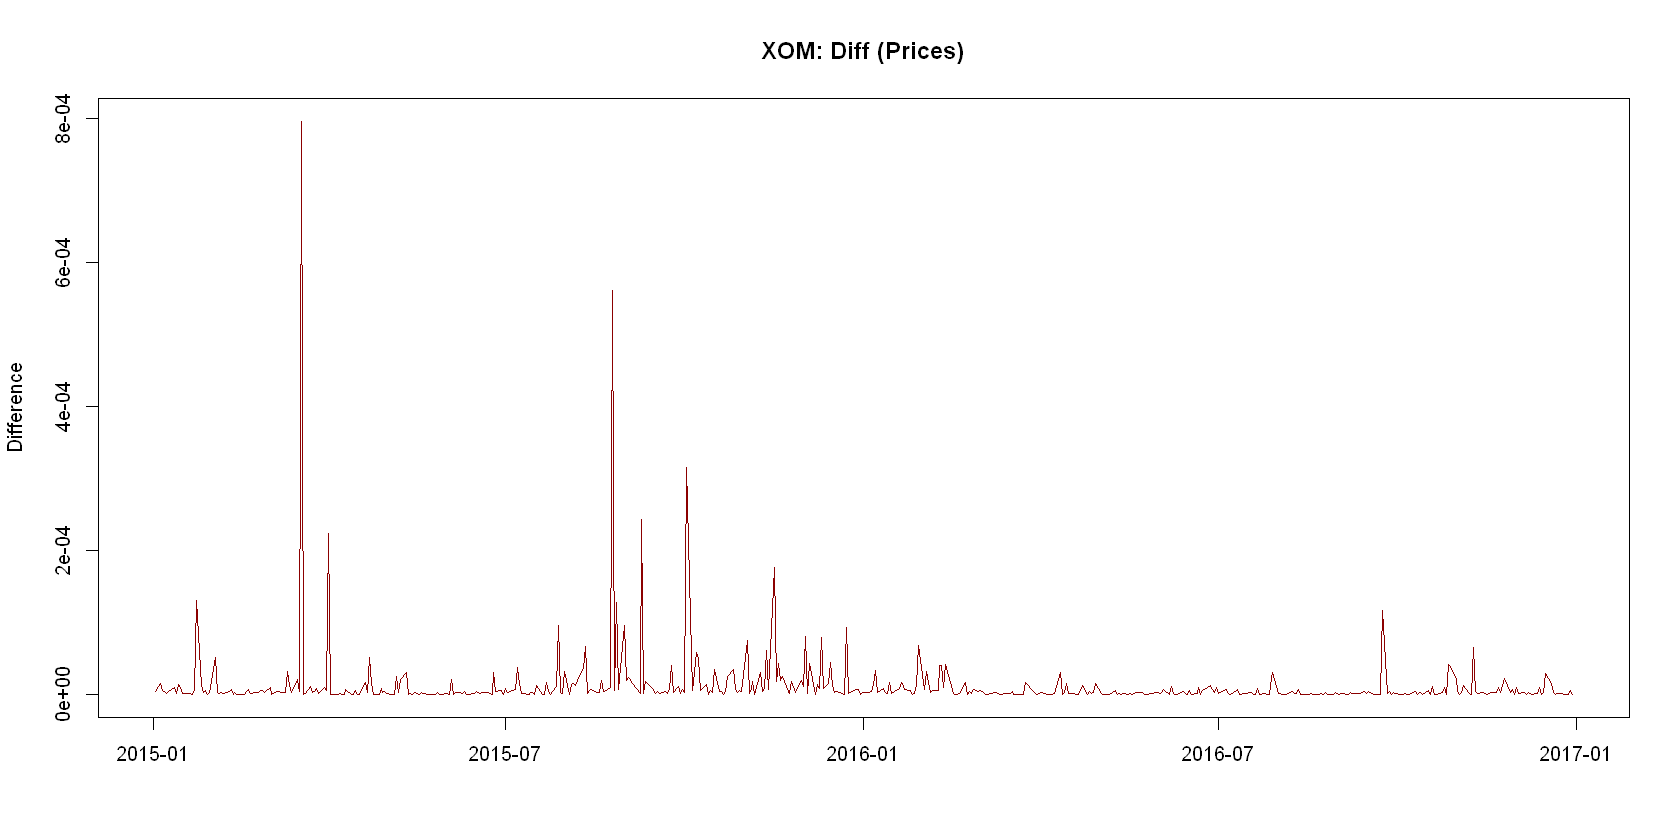

In [64]:
xom_rv_diff_pr  <- xom_combined_pr[, 1] - rowSums(xom_combined_pr[, 2:6])
plot.zoo(xom_rv_diff_pr, col = "darkred", xlab = "", ylab = "Difference", main = "XOM: Diff (Prices)")
cat(sprintf("\n--- XOM Additivity Summary ---\n"))
cat(sprintf("Mean Difference: %e\n", mean(xom_rv_diff_pr, na.rm = TRUE)))
cat(sprintf("Max Difference : %e\n", max(xom_rv_diff_pr,  na.rm = TRUE)))
cat(sprintf("Min Difference : %e\n", min(xom_rv_diff_pr,  na.rm = TRUE)))

### 8.7: shares of sub RVs on the total daily RV

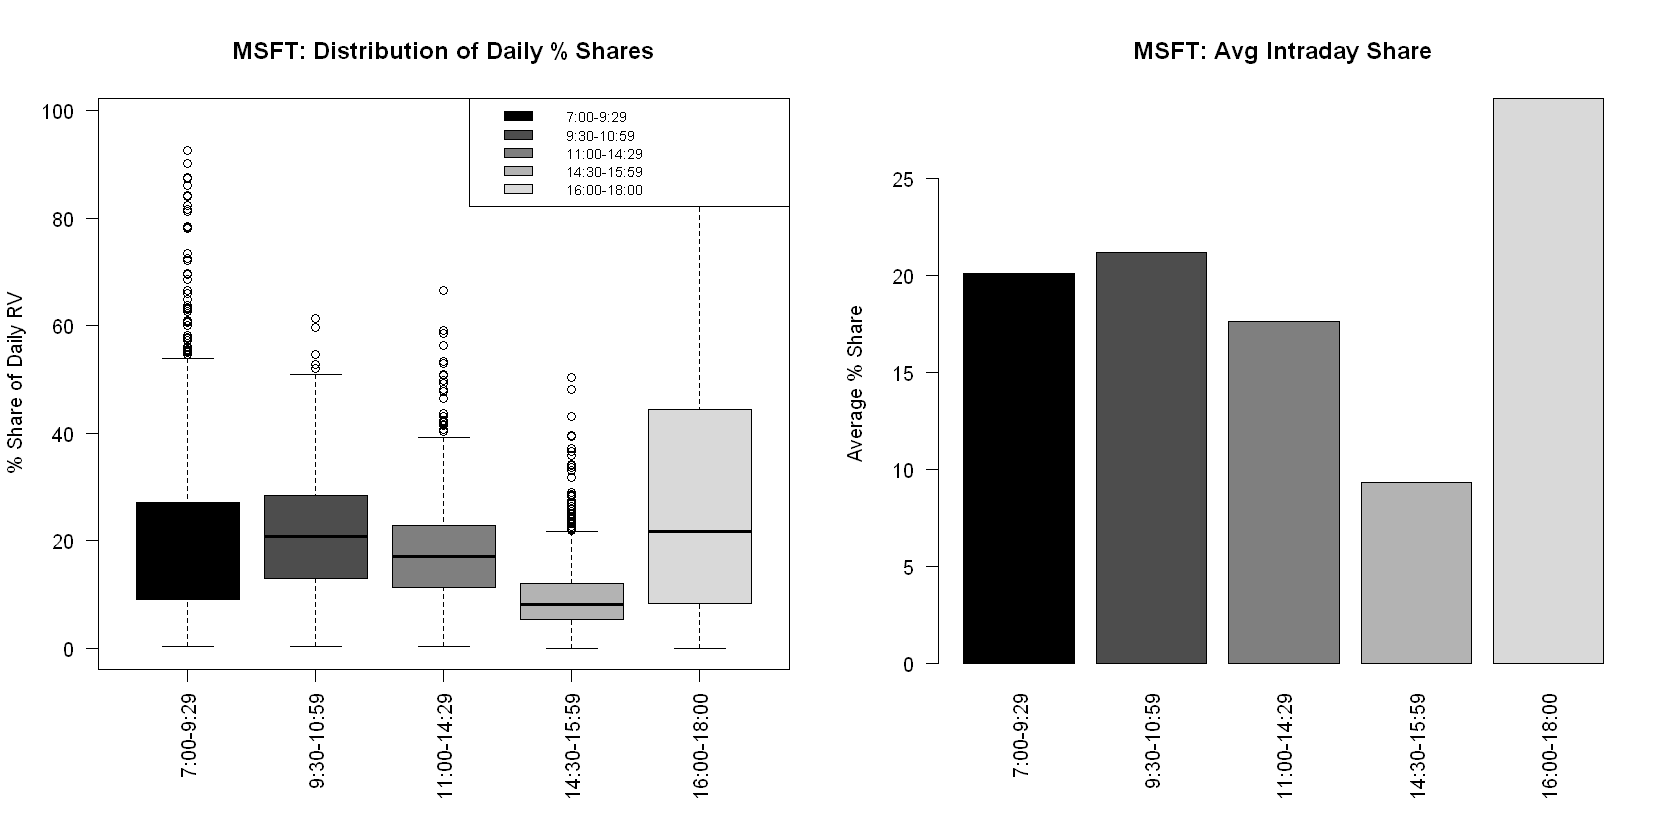

In [81]:
# MSFT
msft_pct_pr <- (msft_combined_pr[, 2:6] / as.numeric(msft_combined_pr[, 1])) * 100
msft_pct_pr[is.na(msft_pct_pr) | msft_pct_pr == Inf] <- 0
colnames(msft_pct_pr) <- labels
msft_avg_pct_pr <- colMeans(msft_pct_pr, na.rm = TRUE)

par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
boxplot(as.data.frame(msft_pct_pr), col = plot_colors, las = 2, 
        ylab = "% Share of Daily RV", main = "MSFT: Distribution of Daily % Shares")
legend("topright", legend = labels, fill = plot_colors, cex = 0.7, bg = "white")
barplot(msft_avg_pct_pr, col = plot_colors, las = 2, ylab = "Average % Share", main = "MSFT: Avg Intraday Share")

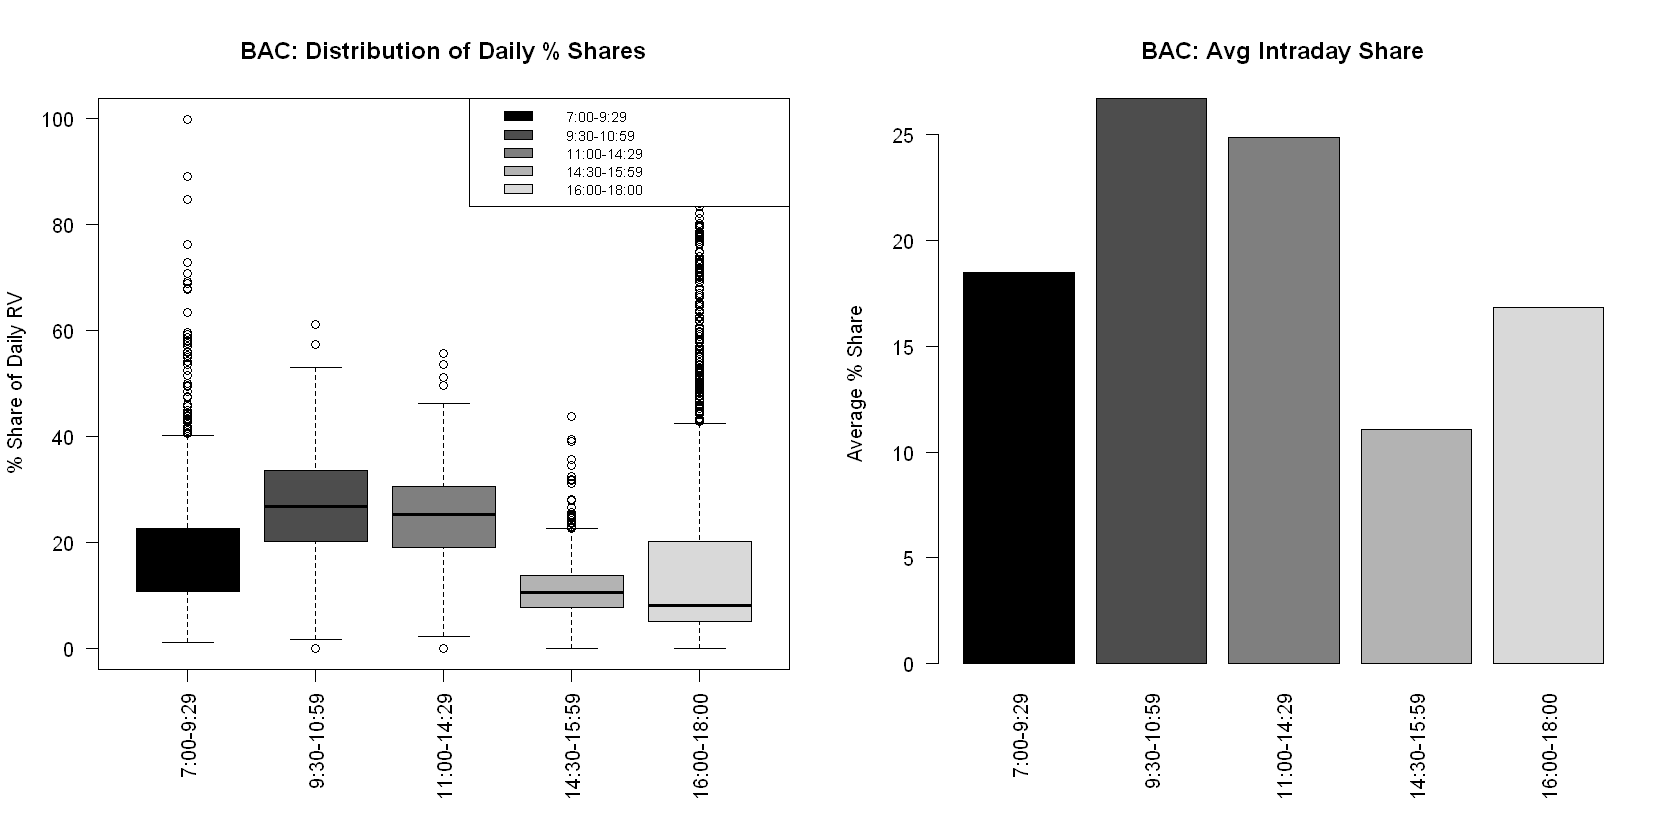

In [80]:
# BAC
bac_pct_pr <- (bac_combined_pr[, 2:6] / as.numeric(bac_combined_pr[, 1])) * 100
bac_pct_pr[is.na(bac_pct_pr) | bac_pct_pr == Inf] <- 0
colnames(bac_pct_pr) <- labels
bac_avg_pct_pr <- colMeans(bac_pct_pr, na.rm = TRUE)

par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
boxplot(as.data.frame(bac_pct_pr), col = plot_colors, las = 2, 
        ylab = "% Share of Daily RV", main = "BAC: Distribution of Daily % Shares")
legend("topright", legend = labels, fill = plot_colors, cex = 0.7, bg = "white")
barplot(bac_avg_pct_pr, col = plot_colors, las = 2, ylab = "Average % Share", main = "BAC: Avg Intraday Share")

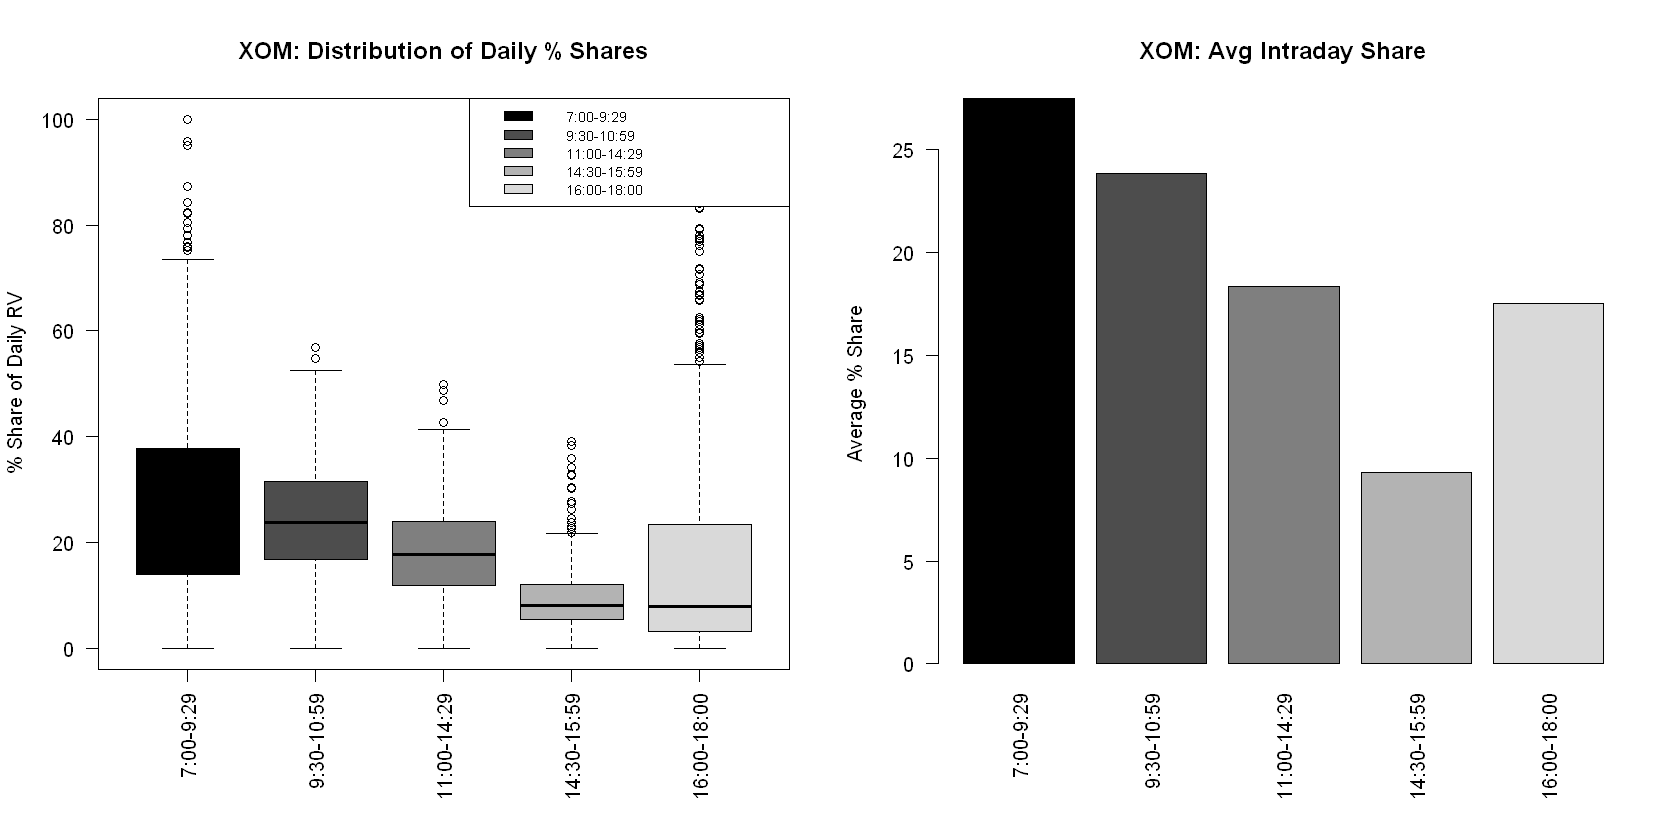

In [78]:
# XOM
xom_pct_pr <- (xom_combined_pr[, 2:6] / as.numeric(xom_combined_pr[, 1])) * 100
xom_pct_pr[is.na(xom_pct_pr) | xom_pct_pr == Inf] <- 0
colnames(xom_pct_pr) <- labels
xom_avg_pct_pr <- colMeans(xom_pct_pr, na.rm = TRUE)

par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
boxplot(as.data.frame(xom_pct_pr), col = plot_colors, las = 2, 
        ylab = "% Share of Daily RV", main = "XOM: Distribution of Daily % Shares")
legend("topright", legend = labels, fill = plot_colors, cex = 0.7, bg = "white")
barplot(xom_avg_pct_pr, col = plot_colors, las = 2, ylab = "Average % Share", main = "XOM: Avg Intraday Share")

## exercise 9: MedRV and BPV

In [86]:
# 1. MSFT Estimators
BV_msft <- rBPCov(rData = msft_xts, makeReturns = TRUE)
index(BV_msft) <- as.Date(index(BV_msft))

MedRV_msft <- rMedRVar(rData = msft_xts, makeReturns = TRUE)
index(MedRV_msft) <- as.Date(index(MedRV_msft))

msft_vol <- cbind(RV_msft, BV_msft, MedRV_msft)
colnames(msft_vol) <- c("RV", "BV", "MedRV")

# 2. BAC Estimators
BV_bac <- rBPCov(rData = bac_xts, makeReturns = TRUE)
index(BV_bac) <- as.Date(index(BV_bac))

MedRV_bac <- rMedRVar(rData = bac_xts, makeReturns = TRUE)
index(MedRV_bac) <- as.Date(index(MedRV_bac))

bac_vol <- cbind(RV_bac, BV_bac, MedRV_bac)
colnames(bac_vol) <- c("RV", "BV", "MedRV")

# 3. XOM Estimators
BV_xom <- rBPCov(rData = xom_xts, makeReturns = TRUE)
index(BV_xom) <- as.Date(index(BV_xom))

MedRV_xom <- rMedRVar(rData = xom_xts, makeReturns = TRUE)
index(MedRV_xom) <- as.Date(index(MedRV_xom))

xom_vol <- cbind(RV_xom, BV_xom, MedRV_xom)
colnames(xom_vol) <- c("RV", "BV", "MedRV")

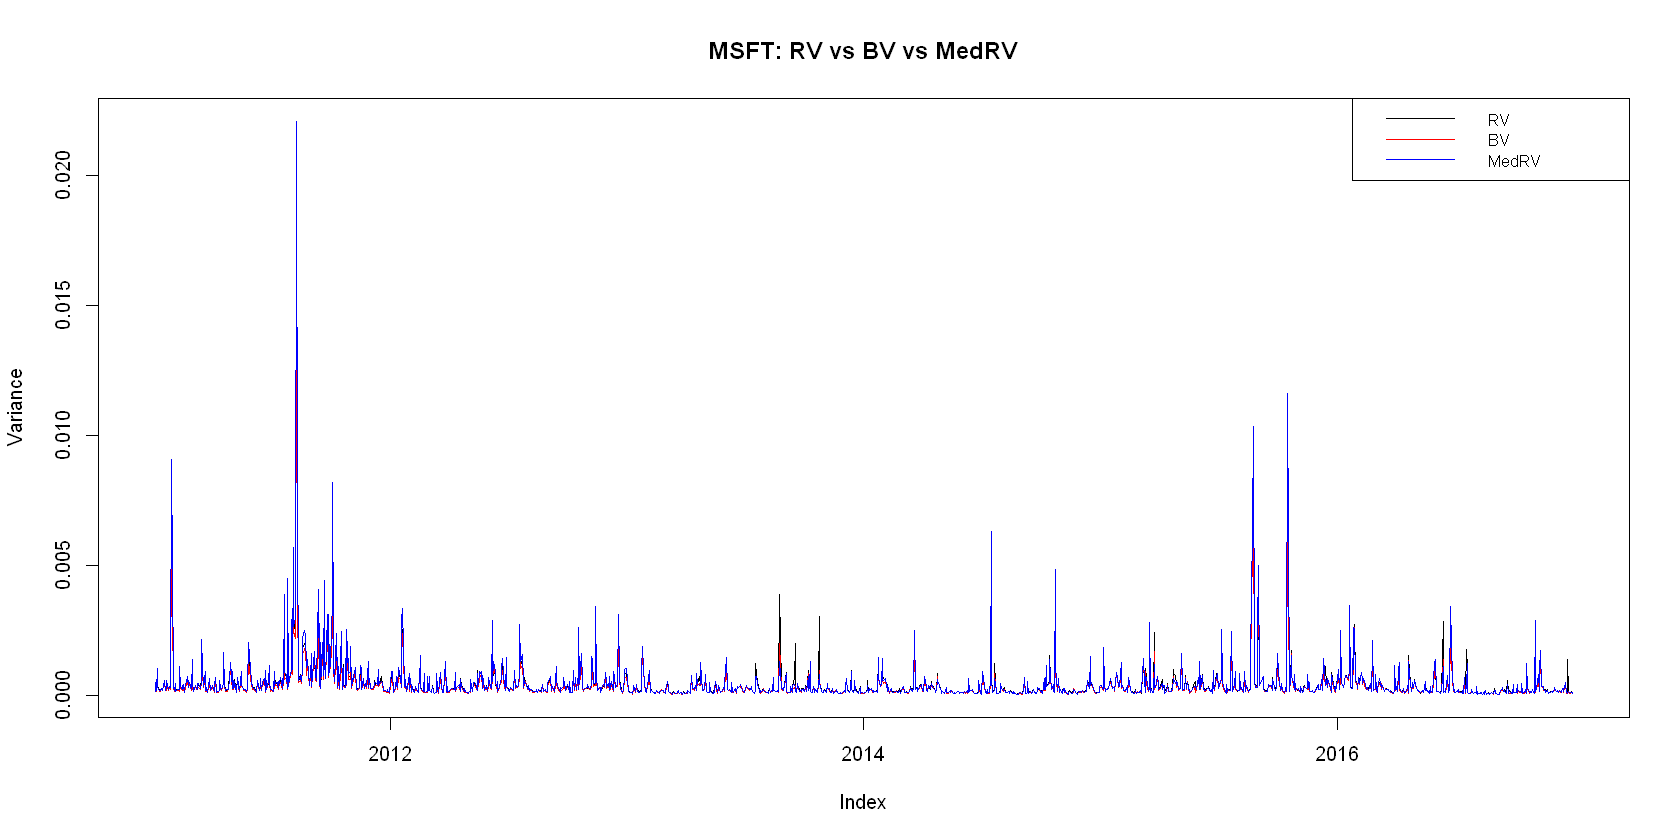

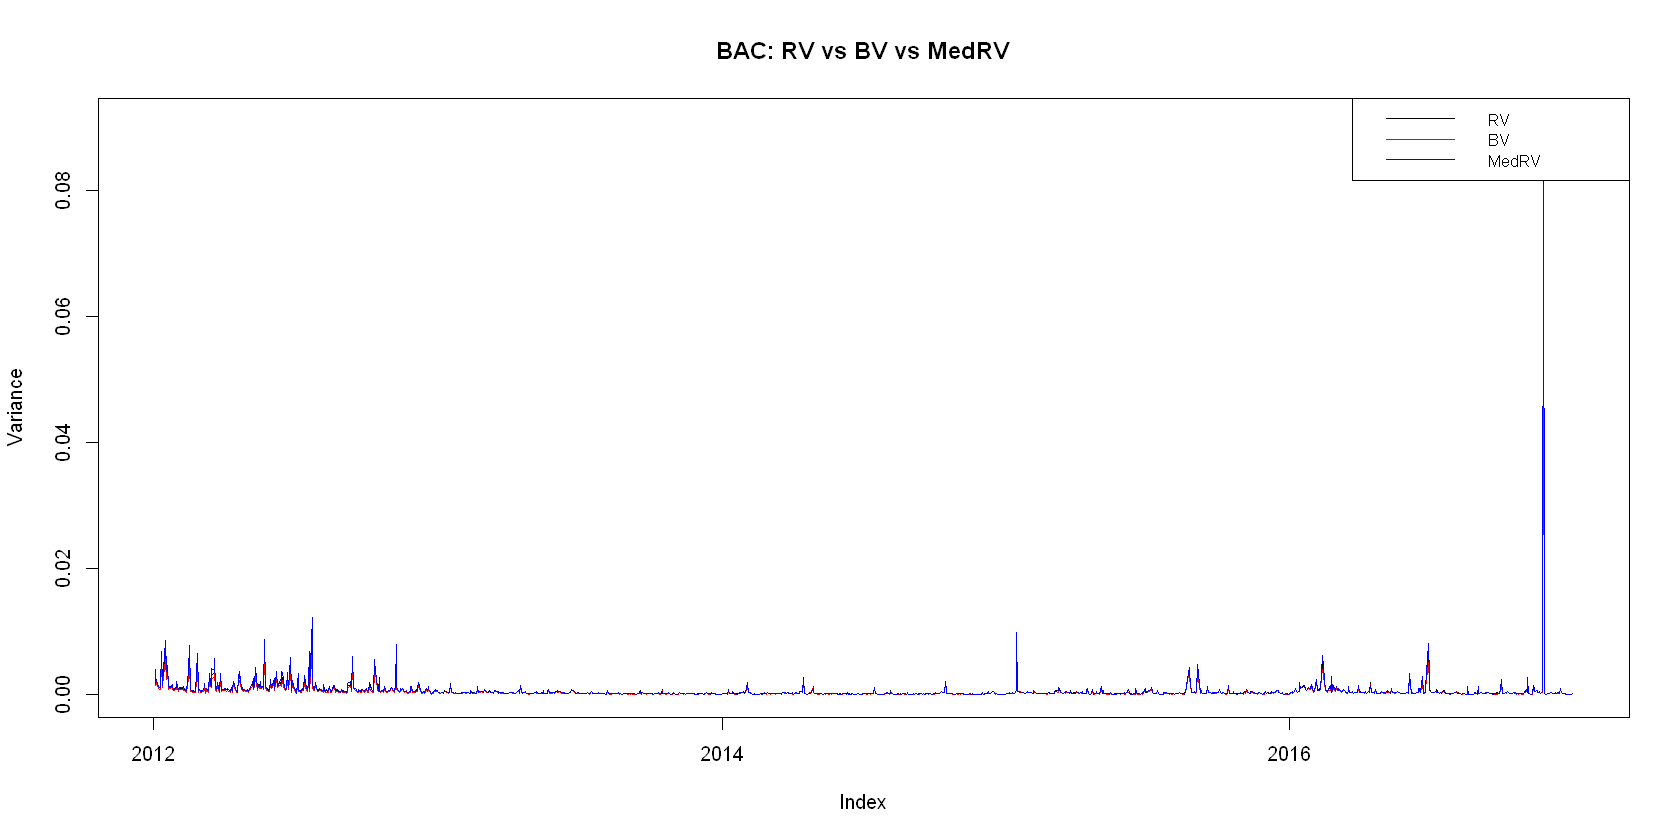

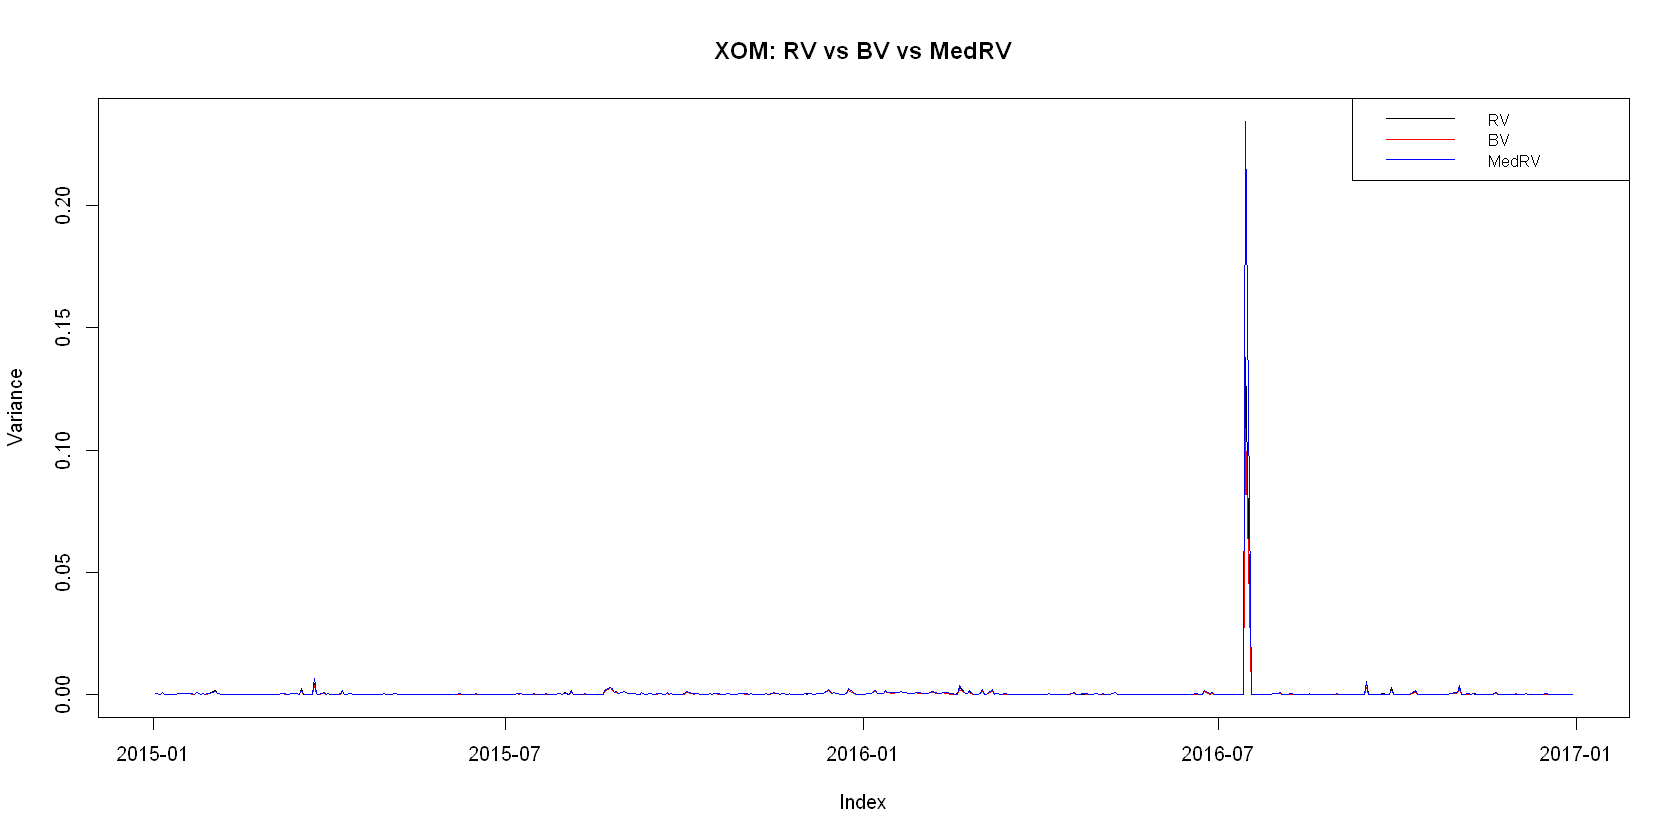

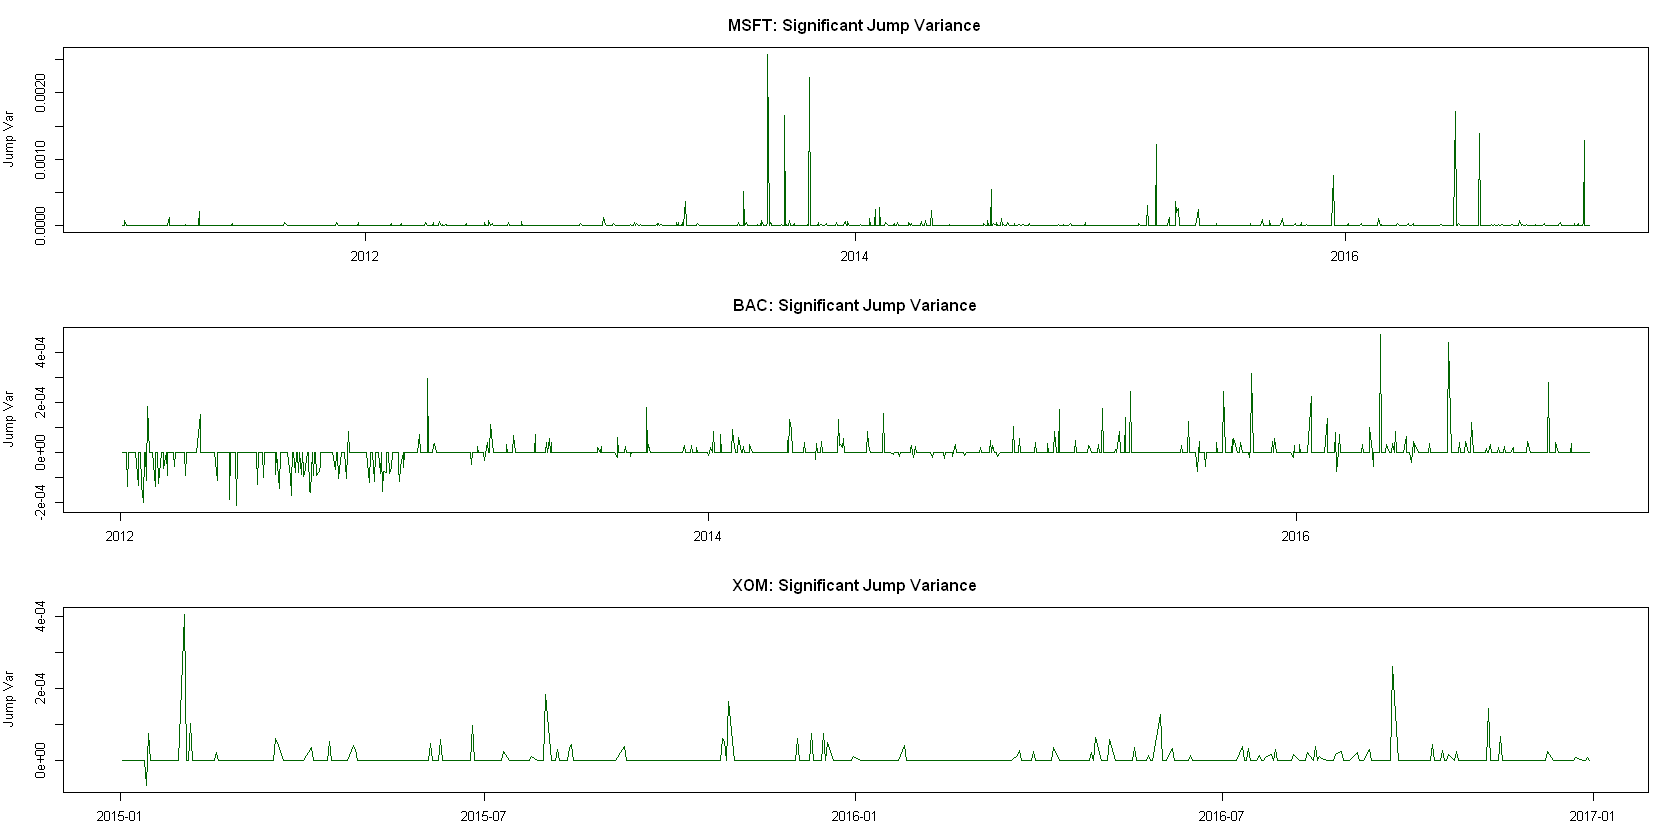

In [96]:
# 1. MSFT 
BV_msft <- rBPCov(rData = msft_xts, makeReturns = TRUE)
index(BV_msft) <- as.Date(index(BV_msft))

MedRV_msft <- rMedRVar(rData = msft_xts, makeReturns = TRUE)
index(MedRV_msft) <- as.Date(index(MedRV_msft))

# Graphical Comparison
plot.zoo(cbind(RV_msft, BV_msft, MedRV_msft), screens = 1, col = c("black", "red", "blue"),
         main = "MSFT: RV vs BV vs MedRV", ylab = "Variance")
legend("topright", legend = c("RV", "BV", "MedRV"), col = c("black", "red", "blue"), lty = 1, cex = 0.8)

# Seminar Jump Logic
j_medRV_msft <- RV_msft - MedRV_msft
jumps_test_medRV_msft <- BNSjumpTest(msft_xts, IVestimator = "rMedRVar", IQestimator = "rMedRQuar", makeReturns = TRUE) 

TT_msft <- nrow(jumps_test_medRV_msft)
I_medRV_msft <- sapply(1:TT_msft, function(j) {
  # Adding a safe check in case a day failed to calculate and returned NA
  if (!is.na(jumps_test_medRV_msft[j, "p.value"]) && jumps_test_medRV_msft[j, "p.value"] < 0.05) { 1 } else { 0 }
})

# Isolate only the statistically significant jumps
J_medRV_msft <- j_medRV_msft * I_medRV_msft


# 2. BAC 
BV_bac <- rBPCov(rData = bac_xts, makeReturns = TRUE)
index(BV_bac) <- as.Date(index(BV_bac))

MedRV_bac <- rMedRVar(rData = bac_xts, makeReturns = TRUE)
index(MedRV_bac) <- as.Date(index(MedRV_bac))

# Graphical Comparison
plot.zoo(cbind(RV_bac, BV_bac, MedRV_bac), screens = 1, col = c("black", "red", "blue"),
         main = "BAC: RV vs BV vs MedRV", ylab = "Variance")
legend("topright", legend = c("RV", "BV", "MedRV"), col = c("black", "red", "blue"), lty = 1, cex = 0.8)

# Seminar Jump Logic
j_medRV_bac <- RV_bac - MedRV_bac
jumps_test_medRV_bac <- BNSjumpTest(bac_xts, IVestimator = "rMedRVar", IQestimator = "rMedRQuar", makeReturns = TRUE) 

TT_bac <- nrow(jumps_test_medRV_bac)
I_medRV_bac <- sapply(1:TT_bac, function(j) {
  if (!is.na(jumps_test_medRV_bac[j, "p.value"]) && jumps_test_medRV_bac[j, "p.value"] < 0.05) { 1 } else { 0 }
})

J_medRV_bac <- j_medRV_bac * I_medRV_bac


# 3. XOM 
BV_xom <- rBPCov(rData = xom_xts, makeReturns = TRUE)
index(BV_xom) <- as.Date(index(BV_xom))

MedRV_xom <- rMedRVar(rData = xom_xts, makeReturns = TRUE)
index(MedRV_xom) <- as.Date(index(MedRV_xom))

# Graphical Comparison
plot.zoo(cbind(RV_xom, BV_xom, MedRV_xom), screens = 1, col = c("black", "red", "blue"),
         main = "XOM: RV vs BV vs MedRV", ylab = "Variance")
legend("topright", legend = c("RV", "BV", "MedRV"), col = c("black", "red", "blue"), lty = 1, cex = 0.8)

# Seminar Jump Logic
j_medRV_xom <- RV_xom - MedRV_xom
jumps_test_medRV_xom <- BNSjumpTest(xom_xts, IVestimator = "rMedRVar", IQestimator = "rMedRQuar", makeReturns = TRUE) 

TT_xom <- nrow(jumps_test_medRV_xom)
I_medRV_xom <- sapply(1:TT_xom, function(j) {
  if (!is.na(jumps_test_medRV_xom[j, "p.value"]) && jumps_test_medRV_xom[j, "p.value"] < 0.05) { 1 } else { 0 }
})

J_medRV_xom <- j_medRV_xom * I_medRV_xom


# Plot the Isolated Significant Jumps
par(mfrow = c(3, 1), mar = c(3, 4, 3, 2))
plot.zoo(J_medRV_msft, col = "darkgreen", main = "MSFT: Significant Jump Variance", ylab = "Jump Var")
plot.zoo(J_medRV_bac, col = "darkgreen", main = "BAC: Significant Jump Variance", ylab = "Jump Var")
plot.zoo(J_medRV_xom, col = "darkgreen", main = "XOM: Significant Jump Variance", ylab = "Jump Var")
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1) # Reset

## exercise 10: compare sqrt(RV) with GARCH

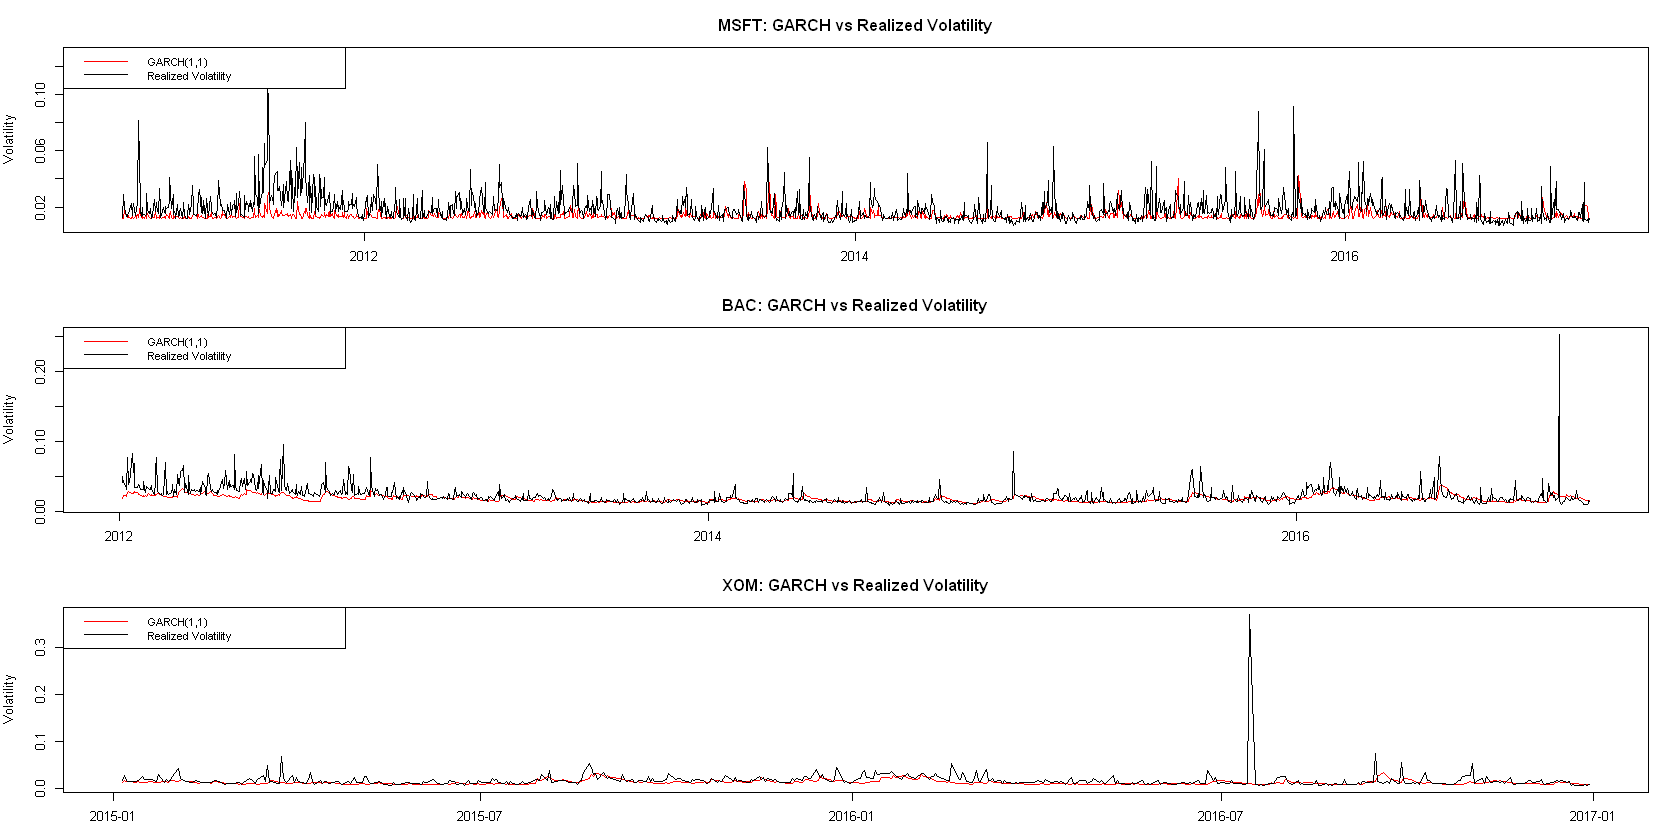

In [97]:
# Extract the last price of each day using endpoints
msft_daily_prices <- msft_xts[endpoints(msft_xts, on = "days")]
bac_daily_prices  <- bac_xts[endpoints(bac_xts, on = "days")]
xom_daily_prices  <- xom_xts[endpoints(xom_xts, on = "days")]

# Calculate daily log returns
msft_daily_ret <- na.omit(diff(log(msft_daily_prices)))
bac_daily_ret  <- na.omit(diff(log(bac_daily_prices)))
xom_daily_ret  <- na.omit(diff(log(xom_daily_prices)))

# Standardize index to Date format to match RV indices perfectly
index(msft_daily_ret) <- as.Date(index(msft_daily_ret))
index(bac_daily_ret)  <- as.Date(index(bac_daily_ret))
index(xom_daily_ret)  <- as.Date(index(xom_daily_ret))

# ---------------------------------------------------------
# 2. Specify the ARMA(0,0)-GARCH(1,1) Model
# ---------------------------------------------------------
garch_spec <- ugarchspec(
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1)),
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  distribution.model = "norm"
)

# ---------------------------------------------------------
# 3. Fit Models and Extract Conditional Volatility
# ---------------------------------------------------------
# MSFT
msft_garch_fit <- ugarchfit(spec = garch_spec, data = msft_daily_ret)
msft_sigma <- xts(sigma(msft_garch_fit), order.by = index(msft_daily_ret))

# BAC
bac_garch_fit <- ugarchfit(spec = garch_spec, data = bac_daily_ret)
bac_sigma <- xts(sigma(bac_garch_fit), order.by = index(bac_daily_ret))

# XOM
xom_garch_fit <- ugarchfit(spec = garch_spec, data = xom_daily_ret)
xom_sigma <- xts(sigma(xom_garch_fit), order.by = index(xom_daily_ret))

# ---------------------------------------------------------
# 4. Merge GARCH Sigma with Realized Volatility (sqrt(RV))
# ---------------------------------------------------------
# Note: RV is calculated as variance, so we MUST take the square root 
# to compare it directly to GARCH sigma (which is standard deviation)

msft_comp <- merge(msft_sigma, sqrt(RV_msft), join = "inner")
colnames(msft_comp) <- c("GARCH", "Realized")

bac_comp <- merge(bac_sigma, sqrt(RV_bac), join = "inner")
colnames(bac_comp) <- c("GARCH", "Realized")

xom_comp <- merge(xom_sigma, sqrt(RV_xom), join = "inner")
colnames(xom_comp) <- c("GARCH", "Realized")

# ---------------------------------------------------------
# 5. Graphical Comparison
# ---------------------------------------------------------
par(mfrow = c(3, 1), mar = c(3, 4, 3, 2))

plot.zoo(msft_comp, screens = 1, col = c("red", "black"), 
         main = "MSFT: GARCH vs Realized Volatility", ylab = "Volatility")
legend("topleft", legend = c("GARCH(1,1)", "Realized Volatility"), col = c("red", "black"), lty = 1, cex = 0.8)

plot.zoo(bac_comp, screens = 1, col = c("red", "black"), 
         main = "BAC: GARCH vs Realized Volatility", ylab = "Volatility")
legend("topleft", legend = c("GARCH(1,1)", "Realized Volatility"), col = c("red", "black"), lty = 1, cex = 0.8)

plot.zoo(xom_comp, screens = 1, col = c("red", "black"), 
         main = "XOM: GARCH vs Realized Volatility", ylab = "Volatility")
legend("topleft", legend = c("GARCH(1,1)", "Realized Volatility"), col = c("red", "black"), lty = 1, cex = 0.8)